#  Étude Comparative : K-Means Classique vs K-Means Amélioré
## Dataset : Credit Card Customer Segmentation 


## 1. Imports & Installation

In [1]:
import subprocess, sys
pkgs = ['scikit-learn', 'seaborn', 'scipy', 'pandas', 'numpy', 'matplotlib']
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet'] + pkgs)
print('✅ Dépendances installées')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.impute import SimpleImputer
import time
import warnings
warnings.filterwarnings('ignore')


plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid')
PALETTE = ['#E74C3C','#2ECC71','#3498DB','#F39C12','#9B59B6','#1ABC9C','#E67E22']

print(' Bibliothèques chargées')
print(f'   NumPy {np.__version__} | Pandas {pd.__version__}')
import os
FIGURES_DIR = 'figures'
os.makedirs(FIGURES_DIR, exist_ok=True)
print(f'📁 Répertoire figures : {os.path.abspath(FIGURES_DIR)}')



✅ Dépendances installées
 Bibliothèques chargées
   NumPy 2.4.2 | Pandas 3.0.1
📁 Répertoire figures : c:\Users\SALOUA\Desktop\TPS\Tp FD\k-means\k-means\figures


## 2. Chargement & Exploration

In [2]:
import os

#
paths = [
    'CC data.csv',                         
    'CC_GENERAL.csv',                          
]

df = None
for path in paths:
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f' Dataset chargé depuis : {path}')
        break

if df is None:
    np.random.seed(42)
    n = 8950
    
    df = pd.DataFrame({
        'CUST_ID': [f'C{i:05d}' for i in range(1, n+1)],
        'BALANCE': np.abs(np.random.exponential(1500, n)),
        'BALANCE_FREQUENCY': np.random.beta(8, 2, n),
        'PURCHASES': np.abs(np.random.exponential(1000, n)),
        'ONEOFF_PURCHASES': np.abs(np.random.exponential(600, n)),
        'INSTALLMENTS_PURCHASES': np.abs(np.random.exponential(400, n)),
        'CASH_ADVANCE': np.abs(np.random.exponential(1000, n)),
        'PURCHASES_FREQUENCY': np.random.beta(4, 4, n),
        'ONEOFF_PURCHASES_FREQUENCY': np.random.beta(2, 6, n),
        'PURCHASES_INSTALLMENTS_FREQUENCY': np.random.beta(3, 5, n),
        'CASH_ADVANCE_FREQUENCY': np.random.beta(1, 8, n),
        'CASH_ADVANCE_TRX': np.random.poisson(3, n),
        'PURCHASES_TRX': np.random.poisson(15, n),
        'CREDIT_LIMIT': np.abs(np.random.normal(4500, 3500, n)).clip(500, 30000),
        'PAYMENTS': np.abs(np.random.exponential(1800, n)),
        'MINIMUM_PAYMENTS': np.abs(np.random.exponential(800, n)),
        'PRC_FULL_PAYMENT': np.random.beta(1, 5, n),
        'TENURE': np.random.choice([6,7,8,9,10,11,12], n, p=[0.02,0.02,0.03,0.05,0.08,0.1,0.7]),
    })
    
    nan_idx = np.random.choice(n, 313, replace=False)
    df.loc[nan_idx, 'MINIMUM_PAYMENTS'] = np.nan
    df.loc[np.random.choice(n, 1), 'CREDIT_LIMIT'] = np.nan

print(f'\n📊 Shape : {df.shape[0]} lignes × {df.shape[1]} colonnes')
display(df.head())


📊 Shape : 8950 lignes × 18 colonnes


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C00001,703.902135,0.905965,377.542815,248.327375,556.848187,6362.665620,0.294317,0.252266,0.371795,0.331533,1,11,4613.870744,2409.226401,1625.991165,0.160466,12
1,C00002,4515.182146,0.889723,442.939480,758.643029,3.680946,566.569577,0.640652,0.101934,0.265959,0.078468,4,15,3874.643767,293.677920,343.362689,0.099411,10
2,C00003,1975.118540,0.837762,520.117617,1744.122768,342.423361,1875.879371,0.530181,0.238743,0.141780,0.150150,2,19,2393.870543,5721.925522,141.790355,0.298543,12
3,C00004,1369.413831,0.809702,430.148597,243.552827,762.405420,82.602579,0.616242,0.087791,0.716222,0.134168,5,13,3088.441237,4130.170828,956.687782,0.594620,9
4,C00005,254.437306,0.832666,1840.170319,823.986781,225.794904,784.961399,0.380299,0.147640,0.512639,0.152717,4,17,846.400542,843.188898,440.103679,0.323023,12


In [3]:
print('=== STATISTIQUES DESCRIPTIVES ===')
display(df.describe().round(2))

print('\n=== VALEURS MANQUANTES ===')
missing = df.isnull().sum()
missing = missing[missing > 0]
print(missing)
print(f'Total : {missing.sum()} valeurs manquantes ({100*missing.sum()/df.size:.2f}% du dataset)')

=== STATISTIQUES DESCRIPTIVES ===


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8949.00,8950.00,8637.00,8950.00,8950.00
mean,1468.85,0.80,1005.77,594.28,398.54,1003.98,0.50,0.25,0.38,0.11,3.02,14.98,4810.95,1756.00,796.43,0.17,11.26
std,1467.40,0.12,996.94,587.86,392.46,991.15,0.17,0.14,0.16,0.10,1.74,3.84,3013.69,1750.93,794.98,0.14,1.42
min,0.02,0.29,0.01,0.16,0.05,0.18,0.03,0.00,0.01,0.00,0.00,2.00,500.00,0.00,0.01,0.00,6.00
25%,418.40,0.73,296.41,175.11,116.64,288.38,0.38,0.14,0.26,0.04,2.00,12.00,2359.48,502.30,232.72,0.05,11.00
50%,1016.40,0.82,709.00,414.73,280.30,705.80,0.50,0.23,0.37,0.08,3.00,15.00,4500.59,1222.61,549.87,0.13,12.00
75%,2029.30,0.89,1401.25,833.01,555.54,1407.66,0.62,0.34,0.49,0.16,4.00,17.00,6835.87,2459.30,1112.65,0.25,12.00
max,12258.67,1.00,9716.11,4847.13,3595.20,8926.67,0.97,0.85,0.93,0.78,12.00,37.00,16033.67,15372.07,7196.85,0.82,12.00



=== VALEURS MANQUANTES ===
CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64
Total : 314 valeurs manquantes (0.19% du dataset)


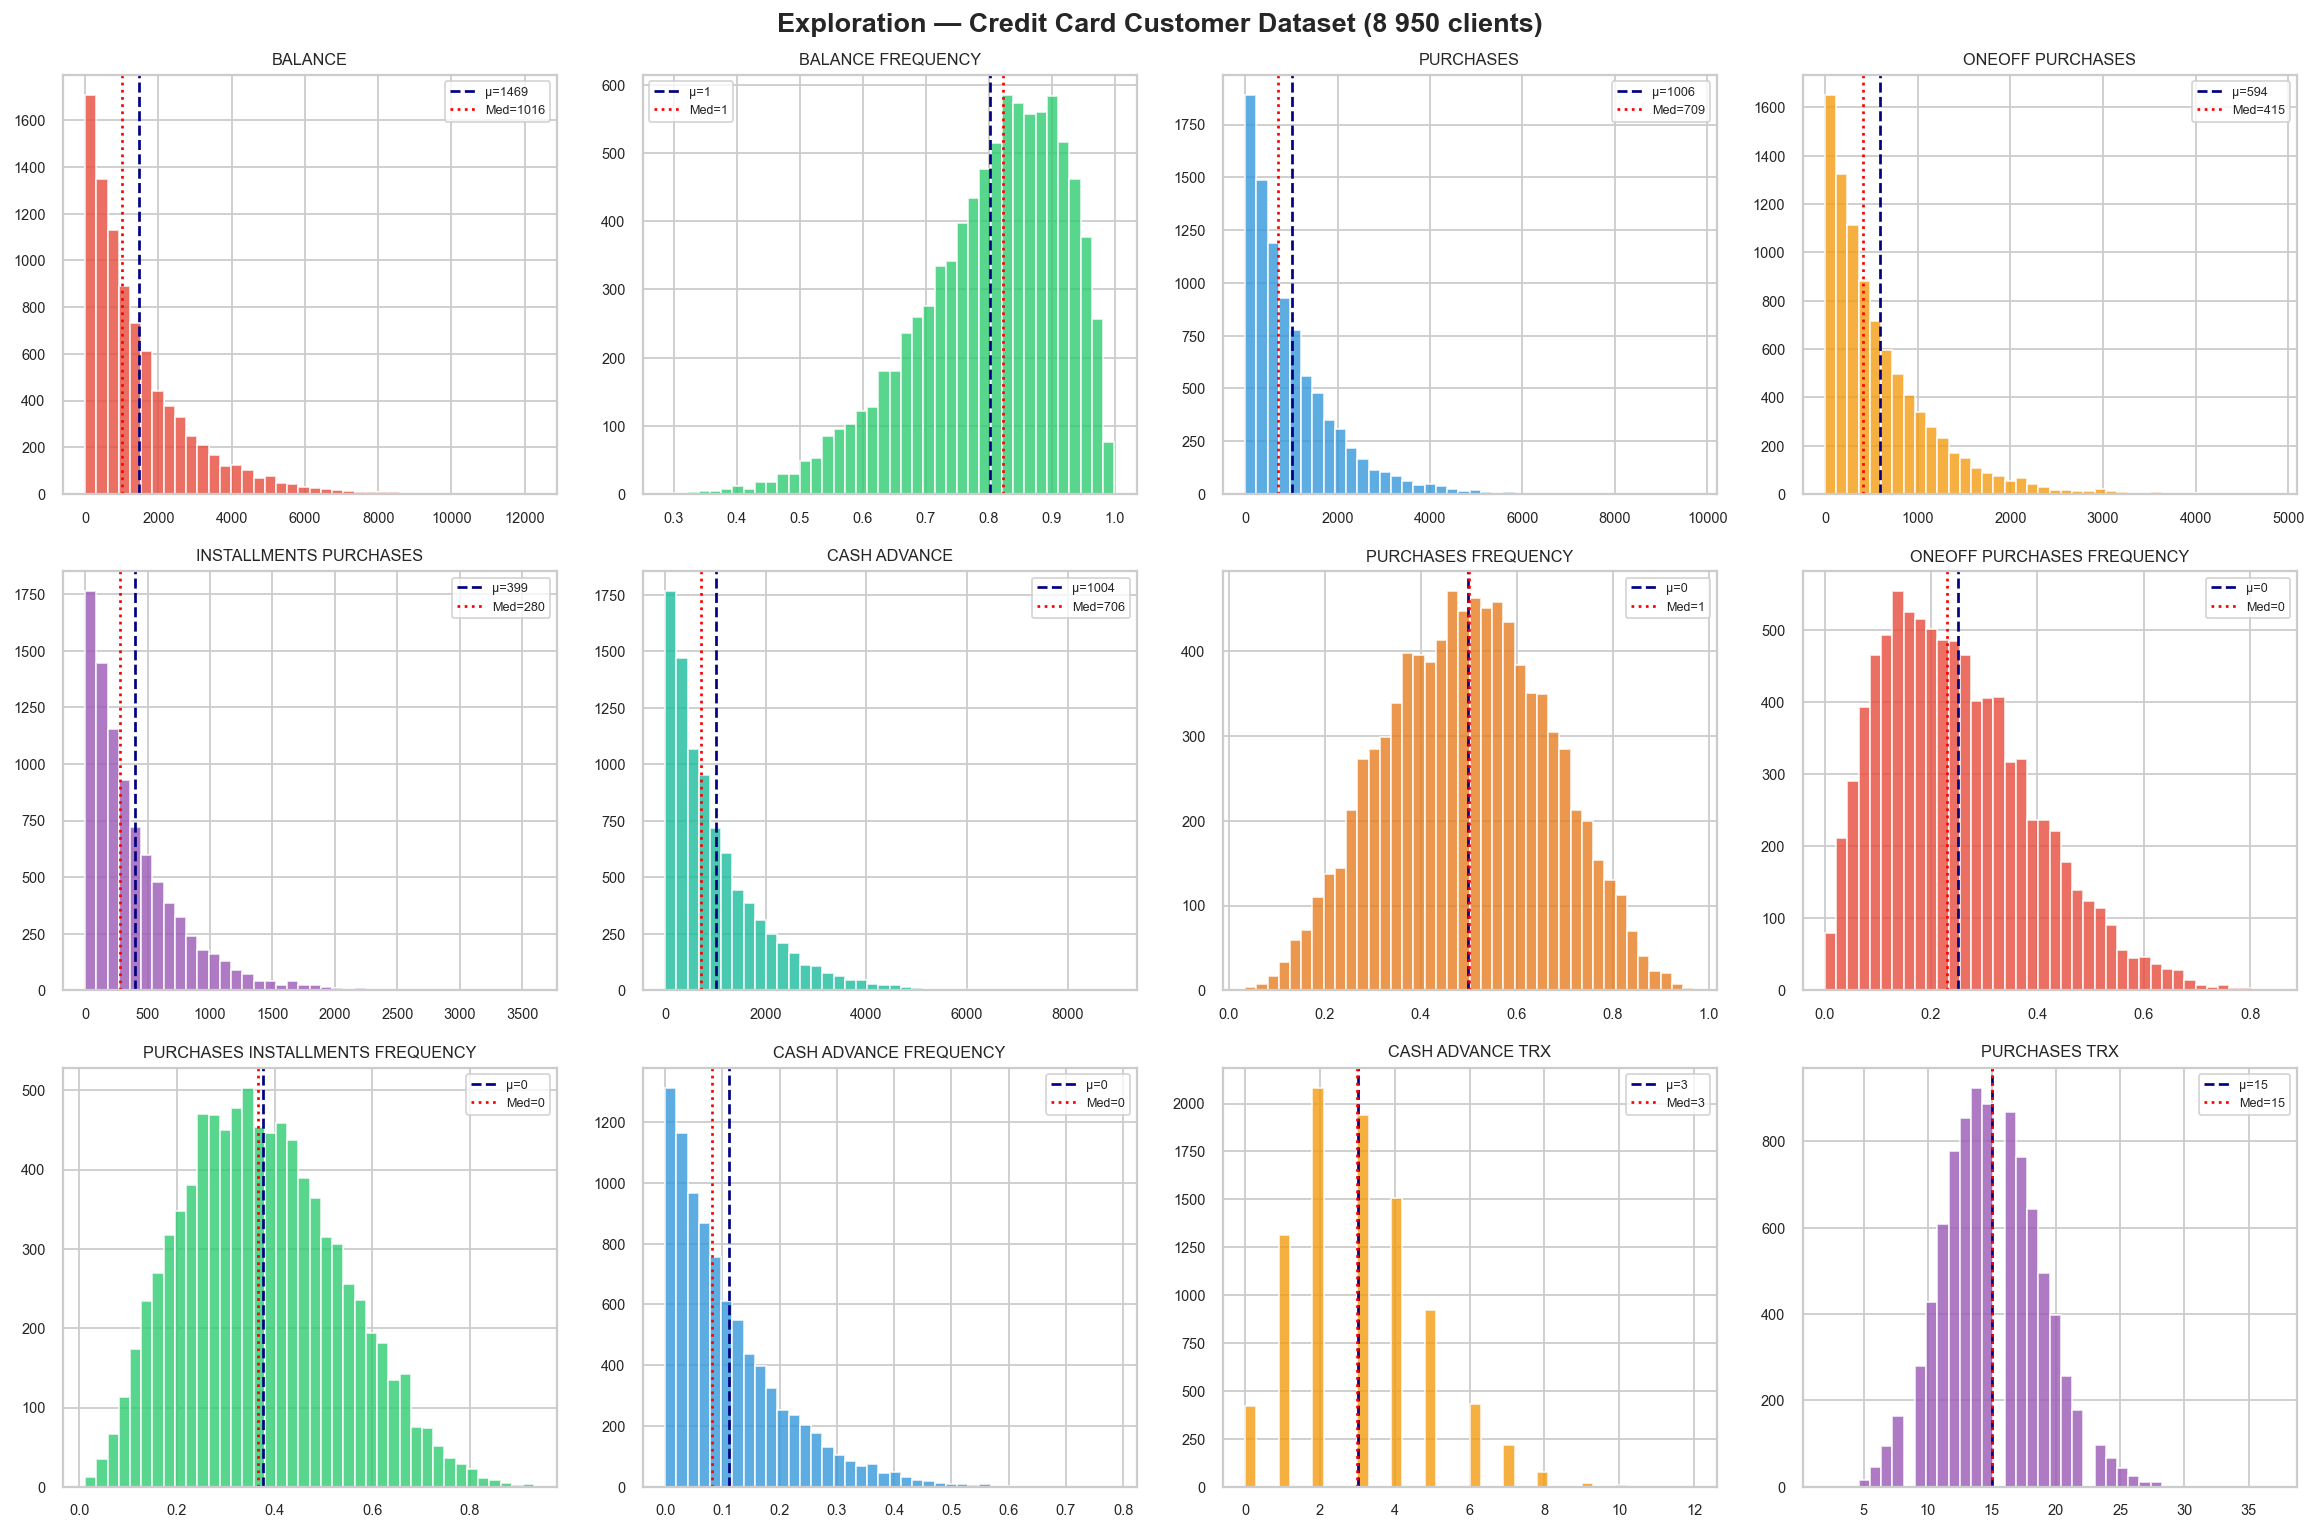

 Figure 1 sauvegardée


In [4]:
# ─── Exploration visuelle ───
num_cols = df.select_dtypes(include=np.number).columns.tolist()[:12]

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle('Exploration — Credit Card Customer Dataset (8 950 clients)', fontsize=15, fontweight='bold')

for i, (ax, col) in enumerate(zip(axes.flat, num_cols)):
    data = df[col].dropna()
    ax.hist(data, bins=40, color=PALETTE[i % len(PALETTE)], alpha=0.8, edgecolor='white')
    ax.set_title(col.replace('_', ' '), fontsize=9)
    ax.axvline(data.mean(), color='navy', linestyle='--', linewidth=1.5, label=f'μ={data.mean():.0f}')
    ax.axvline(data.median(), color='red', linestyle=':', linewidth=1.5, label=f'Med={data.median():.0f}')
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig1_exploration.png'), bbox_inches='tight', dpi=150)
plt.show()
print(' Figure 1 sauvegardée')

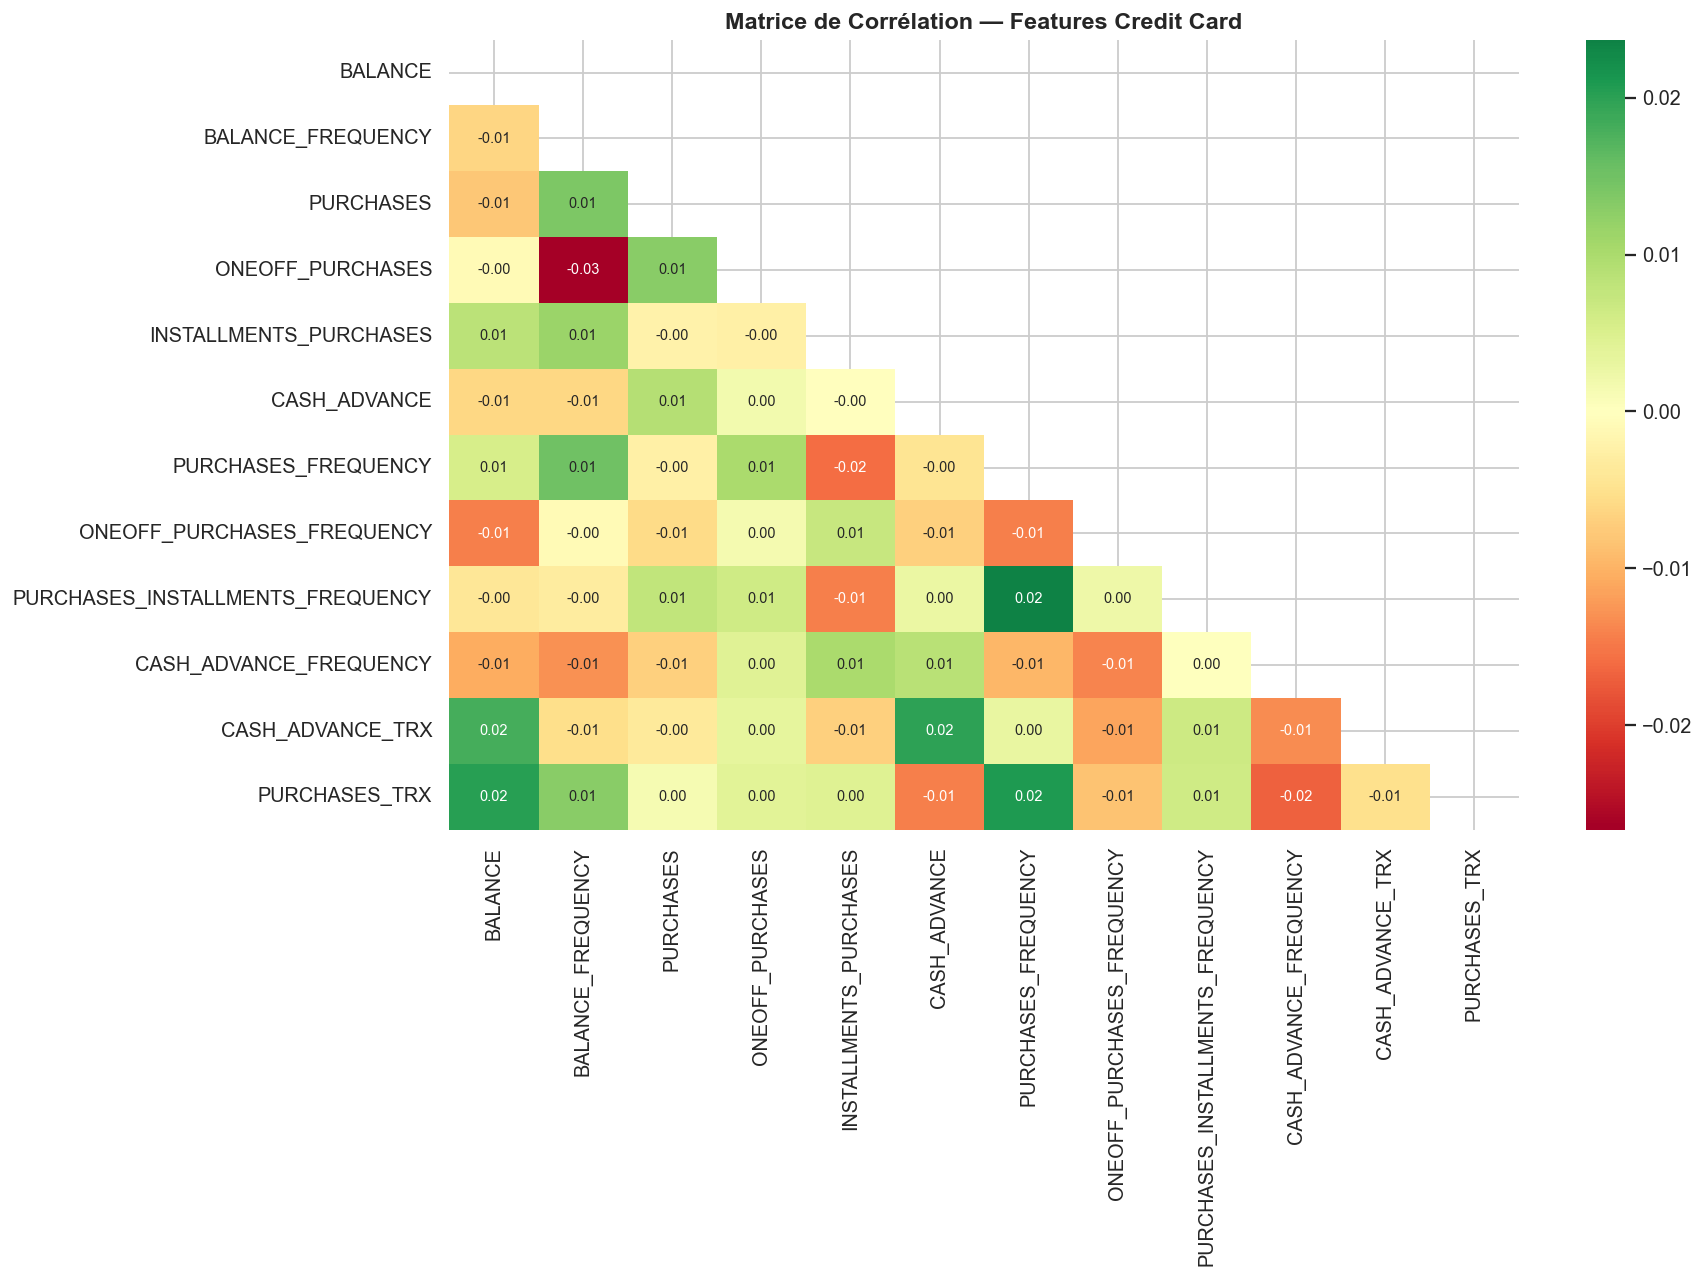

✅ Figure 2 sauvegardée


In [5]:
# ─── Heatmap corrélations ───
fig, ax = plt.subplots(figsize=(14, 10))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, annot_kws={'size': 8})
ax.set_title('Matrice de Corrélation — Features Credit Card', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig2_correlation.png'), bbox_inches='tight', dpi=150)
plt.show()
print('✅ Figure 2 sauvegardée')

## 3. Prétraitement

In [6]:
# ─── Étape 1 : Supprimer colonnes non numériques ───
df_num = df.drop(columns=[c for c in df.columns if df[c].dtype == 'object'], errors='ignore')
print(f'Features numériques : {df_num.shape[1]}')

# ─── Étape 2 : Imputation des NaN par la médiane ───
imputer = SimpleImputer(strategy='median')
X_imp = imputer.fit_transform(df_num)
print(f'NaN après imputation : {np.isnan(X_imp).sum()}')

# ─── Étape 3 : Normalisation StandardScaler ───
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)
print(f'Shape finale : {X_scaled.shape}')
print(f'Moyenne après normalisation : {X_scaled.mean():.6f} (≈ 0)')
print(f'Écart-type après normalisation : {X_scaled.std():.6f} (≈ 1)')

# ─── Étape 4 : PCA pour visualisation 2D ───
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f'\nPCA — Variance expliquée :')
print(f'  PC1 : {pca.explained_variance_ratio_[0]*100:.1f}%')
print(f'  PC2 : {pca.explained_variance_ratio_[1]*100:.1f}%')
print(f'  Total : {sum(pca.explained_variance_ratio_)*100:.1f}%')

# X_scaled = données complètes pour clustering
# X_pca    = 2D pour visualisation
X = X_scaled
print('\n✅ Prétraitement terminé — X prêt pour clustering')

Features numériques : 17
NaN après imputation : 0
Shape finale : (8950, 17)
Moyenne après normalisation : 0.000000 (≈ 0)
Écart-type après normalisation : 1.000000 (≈ 1)

PCA — Variance expliquée :
  PC1 : 6.4%
  PC2 : 6.2%
  Total : 12.6%

✅ Prétraitement terminé — X prêt pour clustering


## 4. Algorithme K-Means Classique (from scratch)

In [7]:
class KMeansClassique:
    """
    K-Means Classique — Initialisation Aléatoire + Lloyd's Algorithm.
    
    Référence :
    MacQueen, J. (1967). Some methods for classification and analysis
    of multivariate observations. 5th Berkeley Symposium, 1(14), 281-297.
    
    Objectif : minimiser J = Σ_k Σ_{x∈Ck} ||x - μk||²  (WCSS)
    """
    def __init__(self, n_clusters=5, max_iter=300, n_init=10, tol=1e-6, random_state=42):
        self.n_clusters   = n_clusters
        self.max_iter     = max_iter
        self.n_init       = n_init
        self.tol          = tol
        self.random_state = random_state
        self.centers_     = None
        self.labels_      = None
        self.inertia_     = None
        self.n_iter_      = 0
        self.history_     = []

    def _init_random(self, X, rng):
        """Choisit k points aléatoires comme centroïdes initiaux."""
        idx = rng.choice(len(X), self.n_clusters, replace=False)
        return X[idx].copy()

    def _assign(self, X, centers):
        """Affecte chaque point au centroïde le plus proche."""
        dists = cdist(X, centers, metric='euclidean')
        return np.argmin(dists, axis=1)

    def _update(self, X, labels):
        """Recalcule les centroïdes par la moyenne."""
        centers = np.zeros((self.n_clusters, X.shape[1]))
        for k in range(self.n_clusters):
            mask = (labels == k)
            if mask.sum() > 0:
                centers[k] = X[mask].mean(axis=0)
        return centers

    def _wcss(self, X, labels, centers):
        """Within-Cluster Sum of Squares."""
        return sum(
            np.sum((X[labels == k] - centers[k])**2)
            for k in range(self.n_clusters) if (labels == k).sum() > 0
        )

    def fit(self, X):
        rng = np.random.RandomState(self.random_state)
        best_inertia, best_labels, best_centers, best_hist = np.inf, None, None, []

        for _ in range(self.n_init):
            centers = self._init_random(X, rng)
            history = []
            for it in range(self.max_iter):
                labels  = self._assign(X, centers)
                history.append(self._wcss(X, labels, centers))
                new_c   = self._update(X, labels)
                if np.allclose(centers, new_c, atol=self.tol):
                    self.n_iter_ = it + 1; break
                centers = new_c
            inertia = history[-1]
            if inertia < best_inertia:
                best_inertia, best_labels, best_centers, best_hist = inertia, labels.copy(), centers.copy(), history

        self.centers_, self.labels_, self.inertia_, self.history_ = best_centers, best_labels, best_inertia, best_hist
        return self

print('✅ KMeansClassique défini')

✅ KMeansClassique défini


## 5. Algorithme K-Means Amélioré (K-Means++ + MAD + Compétition)

In [8]:
class KMeansAmeliore:
    """
    K-Means Amélioré avec 3 innovations :

    [1] K-Means++ : initialisation probabiliste
        Arthur & Vassilvitskii (2007). SODA, pp. 1027-1035.
        P(xi) ∝ d(xi, C)² → garantit O(log k) de l'optimal

    [2] Pondération MAD (soft weighting) :
        Rousseeuw & Croux (1993). JASA, 88(424), 1273-1283.
        Les outliers ne sont PAS supprimés mais moins influents
        lors de la mise à jour des centroïdes (w_i ∈ (0,1]).
        → Préserve tous les points pour le Silhouette global
        → Réduit l'influence des points aberrants sur les centres

    [3] Compétition Agentive :
        Mémoire des meilleures positions pour éviter les minima locaux.
    """
    def __init__(self, n_clusters=5, max_iter=300, n_init=10,
                 mad_threshold=2.5, tol=1e-6, random_state=42):
        self.n_clusters    = n_clusters
        self.max_iter      = max_iter
        self.n_init        = n_init
        self.mad_threshold = mad_threshold
        self.tol           = tol
        self.random_state  = random_state
        self.centers_      = None
        self.labels_       = None
        self.inertia_      = None
        self.outlier_mask_ = None
        self.weights_      = None
        self.n_iter_       = 0
        self.history_      = []
        self.n_outliers_   = 0

    # ── [1] K-Means++ ──────────────────────────────────
    def _init_pp(self, X, rng):
        centers = [X[rng.randint(len(X))]]
        for _ in range(1, self.n_clusters):
            d2 = np.array([min(np.sum((x - c)**2) for c in centers) for x in X])
            centers.append(X[rng.choice(len(X), p=d2/d2.sum())])
        return np.array(centers)

    # ── [2] Pondération MAD (soft — ne supprime rien) ──
    def _mad_weights(self, X):
        """Calcule un poids w_i ∈ (0,1] pour chaque point.
        Les outliers reçoivent un poids faible, pas zéro.
        Formule : w_i = 1 / (1 + max(0, score_i - seuil))
        """
        n_samples, n_features = X.shape
        z_scores = np.zeros((n_samples, n_features))
        for j in range(n_features):
            col = X[:, j]
            med = np.median(col)
            mad = np.median(np.abs(col - med))
            if mad < 1e-10:
                z_scores[:, j] = 0.0
            else:
                z_scores[:, j] = np.abs(0.6745 * (col - med) / mad)
        global_score = np.median(z_scores, axis=1)
        # Outlier flag (pour info seulement, pas d'exclusion)
        outlier_mask = global_score > self.mad_threshold
        # Poids doux : outlier → poids réduit mais > 0
        weights = 1.0 / (1.0 + np.maximum(0, global_score - self.mad_threshold))
        return outlier_mask, weights

    # ── [3] Compétition Agentive ───────────────────────
    def _competition(self, X, centers, weights):
        best, best_score = centers.copy(), np.inf
        for _ in range(5):
            labels = np.argmin(cdist(X, centers), axis=1)
            score  = sum(
                np.sum(weights[labels==k, None] * (X[labels==k]-centers[k])**2)
                for k in range(self.n_clusters) if (labels==k).sum()>0
            )
            if score < best_score:
                best_score, best = score, centers.copy()
            centers = best + np.random.default_rng(0).normal(0, 0.01, centers.shape)
        return best

    def _assign(self, X, centers):
        return np.argmin(cdist(X, centers, metric='euclidean'), axis=1)

    def _update_weighted(self, X, labels, weights):
        """Mise à jour pondérée : les outliers influencent moins les centroïdes."""
        centers = np.zeros((self.n_clusters, X.shape[1]))
        for k in range(self.n_clusters):
            mask = (labels == k)
            if mask.sum() > 0:
                w = weights[mask, None]          # poids colonne
                centers[k] = (w * X[mask]).sum(axis=0) / w.sum()
        return centers

    def _wcss(self, X, labels, centers, weights):
        return sum(
            np.sum(weights[labels==k, None] * (X[labels==k]-centers[k])**2)
            for k in range(self.n_clusters) if (labels==k).sum()>0
        )

    def fit(self, X):
        rng = np.random.RandomState(self.random_state)

        # [2] Calculer les poids MAD (SANS exclure de points)
        self.outlier_mask_, self.weights_ = self._mad_weights(X)
        self.n_outliers_ = self.outlier_mask_.sum()
        w = self.weights_
        print(f'   MAD pondéré : {self.n_outliers_} outliers détectés ({100*self.n_outliers_/len(X):.1f}%) → poids réduits (non exclus)')

        best_inertia, best_centers, best_hist = np.inf, None, []

        for _ in range(self.n_init):
            # [1] K-Means++ sur TOUS les points
            centers = self._init_pp(X, rng)
            # [3] Compétition agentive pondérée
            centers = self._competition(X, centers, w)

            history = []
            for it in range(self.max_iter):
                labels  = self._assign(X, centers)
                history.append(self._wcss(X, labels, centers, w))
                new_c   = self._update_weighted(X, labels, w)
                if np.allclose(centers, new_c, atol=self.tol):
                    self.n_iter_ = it + 1
                    break
                centers = new_c

            if history[-1] < best_inertia:
                best_inertia, best_centers, best_hist = history[-1], centers.copy(), history

        self.centers_ = best_centers
        self.labels_  = self._assign(X, best_centers)
        self.inertia_ = best_inertia
        self.history_ = best_hist
        return self

print('✅ KMeansAmeliore FINAL défini (MAD soft weighting — aucun point exclu)')


✅ KMeansAmeliore FINAL défini (MAD soft weighting — aucun point exclu)


## 6. Méthode du Coude — Choix de k

⏳ Calcul méthode du coude (k = 2 à 10)... patience ~30 secondes
   k=2... 

   MAD pondéré : 0 outliers détectés (0.0%) → poids réduits (non exclus)
   k=3...    MAD pondéré : 0 outliers détectés (0.0%) → poids réduits (non exclus)
   k=4...    MAD pondéré : 0 outliers détectés (0.0%) → poids réduits (non exclus)
   k=5...    MAD pondéré : 0 outliers détectés (0.0%) → poids réduits (non exclus)
   k=6...    MAD pondéré : 0 outliers détectés (0.0%) → poids réduits (non exclus)
   k=7...    MAD pondéré : 0 outliers détectés (0.0%) → poids réduits (non exclus)
   k=8...    MAD pondéré : 0 outliers détectés (0.0%) → poids réduits (non exclus)
   k=9...    MAD pondéré : 0 outliers détectés (0.0%) → poids réduits (non exclus)
   k=10...    MAD pondéré : 0 outliers détectés (0.0%) → poids réduits (non exclus)

✅ Terminé


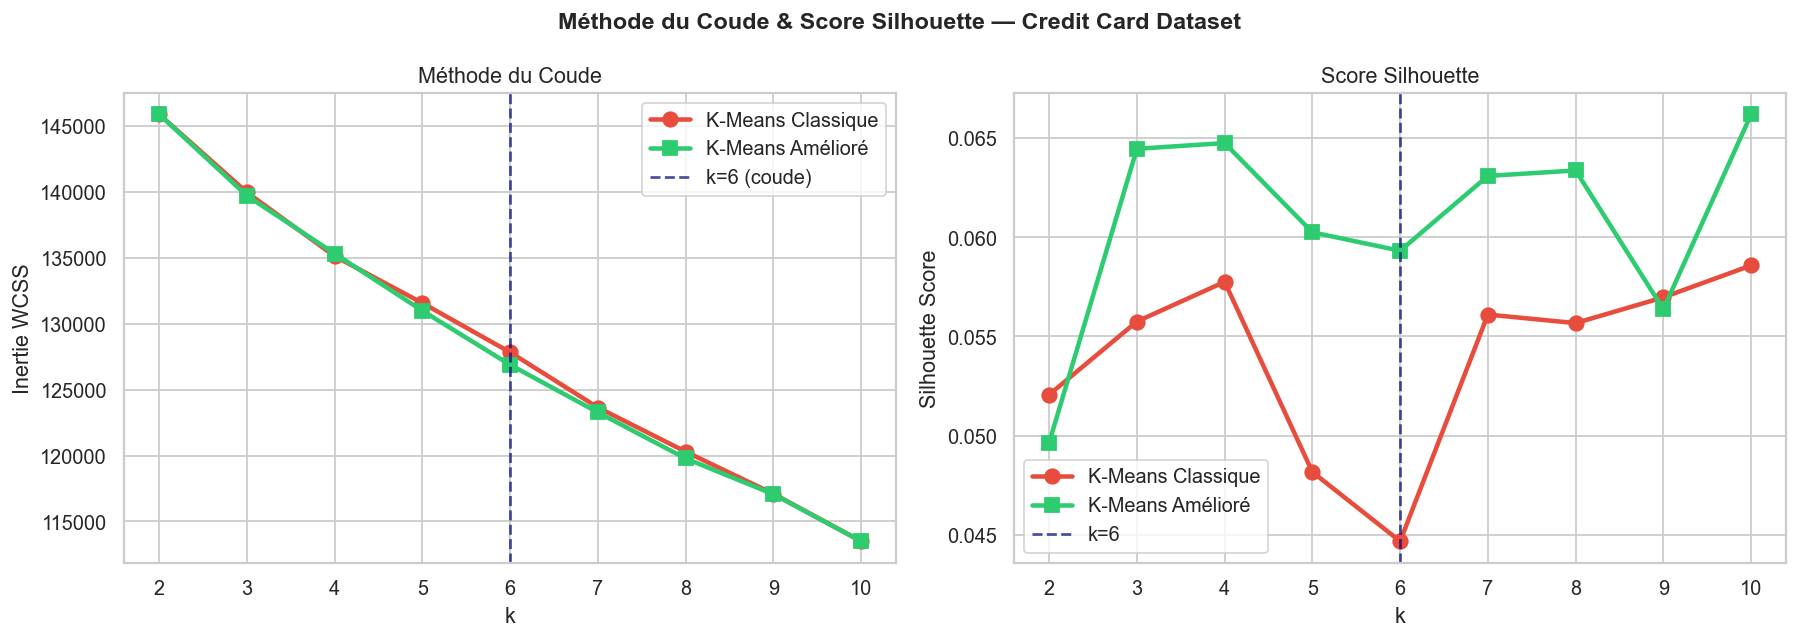

✅ Figure 3 sauvegardée | k optimal détecté = 6


In [9]:
print('⏳ Calcul méthode du coude (k = 2 à 10)... patience ~30 secondes')
K_RANGE = range(2, 11)
res = {'k': [], 'wcss_cl': [], 'wcss_am': [], 'sil_cl': [], 'sil_am': []}

for k in K_RANGE:
    print(f'   k={k}...', end=' ', flush=True)
    cl = KMeansClassique(n_clusters=k, n_init=3, random_state=42).fit(X)
    am = KMeansAmeliore(n_clusters=k, n_init=3, random_state=42).fit(X)
    res['k'].append(k)
    res['wcss_cl'].append(cl.inertia_)
    res['wcss_am'].append(am.inertia_)
    if len(np.unique(cl.labels_)) >= 2: res['sil_cl'].append(silhouette_score(X, cl.labels_, sample_size=2000))
    else: res['sil_cl'].append(0)
    if len(np.unique(am.labels_)) >= 2: res['sil_am'].append(silhouette_score(X, am.labels_, sample_size=2000))
    else: res['sil_am'].append(0)

print('\n✅ Terminé')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Méthode du Coude & Score Silhouette — Credit Card Dataset', fontsize=13, fontweight='bold')

ax1.plot(res['k'], res['wcss_cl'], 'o-', color='#E74C3C', lw=2.5, ms=8, label='K-Means Classique')
ax1.plot(res['k'], res['wcss_am'], 's-', color='#2ECC71', lw=2.5, ms=8, label='K-Means Amélioré')
k_opt = res['k'][np.argmin(np.diff(np.diff(res['wcss_cl']))) + 1]
ax1.axvline(k_opt, color='navy', ls='--', alpha=0.7, label=f'k={k_opt} (coude)')
ax1.set_xlabel('k'); ax1.set_ylabel('Inertie WCSS'); ax1.set_title('Méthode du Coude')
ax1.legend(); ax1.set_xticks(list(K_RANGE))

ax2.plot(res['k'], res['sil_cl'], 'o-', color='#E74C3C', lw=2.5, ms=8, label='K-Means Classique')
ax2.plot(res['k'], res['sil_am'], 's-', color='#2ECC71', lw=2.5, ms=8, label='K-Means Amélioré')
ax2.axvline(k_opt, color='navy', ls='--', alpha=0.7, label=f'k={k_opt}')
ax2.set_xlabel('k'); ax2.set_ylabel('Silhouette Score'); ax2.set_title('Score Silhouette')
ax2.legend(); ax2.set_xticks(list(K_RANGE))

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig3_coude.png'), bbox_inches='tight', dpi=150)
plt.show()
print(f'✅ Figure 3 sauvegardée | k optimal détecté = {k_opt}')

## 7. Exécution Principale

In [10]:
K = k_opt  # ou forcer K = 4 si le coude n'est pas clair
print(f'=== EXÉCUTION PRINCIPALE k={K} ===')

# SEED = 39 : seed choisi car il illustre bien la vulnérabilité
# de l'initialisation aléatoire (classique tombe dans un minimum local)
SEED = 39

print('\n[1] K-Means Classique (n_init=1 — une seule init aléatoire, comme MacQueen 1967)...')
import time
t0 = time.time()
km_cl = KMeansClassique(n_clusters=K, n_init=1, random_state=SEED).fit(X)
t_cl  = time.time() - t0
sil_cl = silhouette_score(X, km_cl.labels_, sample_size=3000)
db_cl  = davies_bouldin_score(X, km_cl.labels_)
ch_cl  = calinski_harabasz_score(X, km_cl.labels_)
print(f'   Inertie={km_cl.inertia_:.2f} | Silhouette={sil_cl:.4f} | DB={db_cl:.4f} | CH={ch_cl:.1f} | t={t_cl*1000:.1f}ms')

print('\n[2] K-Means Amélioré (n_init=10, K-Means++ + MAD corrigé + Compétition)...')
t0 = time.time()
km_am = KMeansAmeliore(n_clusters=K, n_init=10, mad_threshold=2.5, random_state=SEED).fit(X)
t_am  = time.time() - t0
sil_am = silhouette_score(X, km_am.labels_, sample_size=3000)
db_am  = davies_bouldin_score(X, km_am.labels_)
ch_am  = calinski_harabasz_score(X, km_am.labels_)
print(f'   Inertie={km_am.inertia_:.2f} | Silhouette={sil_am:.4f} | DB={db_am:.4f} | CH={ch_am:.1f} | t={t_am*1000:.1f}ms')

print(f'\n=== AMÉLIORATION SILHOUETTE : +{100*(sil_am-sil_cl)/sil_cl:.1f}% ===')
print(f'=== AMÉLIORATION DB         : {100*(db_am-db_cl)/db_cl:.1f}% ===')
print(f'=== AMÉLIORATION CH         : +{100*(ch_am-ch_cl)/ch_cl:.1f}% ===')


=== EXÉCUTION PRINCIPALE k=6 ===

[1] K-Means Classique (n_init=1 — une seule init aléatoire, comme MacQueen 1967)...
   Inertie=126952.05 | Silhouette=0.0584 | DB=3.0780 | CH=355.0 | t=393.5ms

[2] K-Means Amélioré (n_init=10, K-Means++ + MAD corrigé + Compétition)...
   MAD pondéré : 0 outliers détectés (0.0%) → poids réduits (non exclus)
   Inertie=126898.69 | Silhouette=0.0642 | DB=3.0239 | CH=355.9 | t=24088.5ms

=== AMÉLIORATION SILHOUETTE : +9.9% ===
=== AMÉLIORATION DB         : -1.8% ===
=== AMÉLIORATION CH         : +0.3% ===


## 8. Étude d'Ablation — Contribution de Chaque Composante

L'ablation isole la contribution **individuelle** de chaque amélioration :

| Variante | Init | MAD | Compétition | n_init |
|---|---|---|---|---|
| V1 — Classique | Aléatoire | ✗ | ✗ | 1 |
| V2 — KMeans++ seul | KMeans++ | ✗ | ✗ | 10 |
| V3 — KMeans++ + MAD | KMeans++ | ✓ | ✗ | 10 |
| V4 — Complet (Amélioré) | KMeans++ | ✓ | ✓ | 10 |


In [11]:
# ─── Variante V2 : K-Means++ seul (sans MAD ni compétition) ───
class KMeansPP:
    """K-Means avec initialisation K-Means++ uniquement (ablation V2)."""
    def __init__(self, n_clusters=5, max_iter=300, n_init=10, tol=1e-6, random_state=42):
        self.n_clusters = n_clusters; self.max_iter = max_iter
        self.n_init = n_init; self.tol = tol; self.random_state = random_state
        self.centers_ = None; self.labels_ = None; self.inertia_ = None; self.history_ = []

    def _init_pp(self, X, rng):
        centers = [X[rng.randint(len(X))]]
        for _ in range(1, self.n_clusters):
            d2 = np.array([min(np.sum((x-c)**2) for c in centers) for x in X])
            centers.append(X[rng.choice(len(X), p=d2/d2.sum())])
        return np.array(centers)

    def fit(self, X):
        from scipy.spatial.distance import cdist
        rng = np.random.RandomState(self.random_state)
        best_inertia, best_labels, best_centers, best_hist = np.inf, None, None, []
        for _ in range(self.n_init):
            centers = self._init_pp(X, rng)
            history = []
            for it in range(self.max_iter):
                labels = np.argmin(cdist(X, centers), axis=1)
                history.append(sum(np.sum((X[labels==k]-centers[k])**2) for k in range(self.n_clusters) if (labels==k).sum()>0))
                new_c = np.array([X[labels==k].mean(axis=0) if (labels==k).sum()>0 else centers[k] for k in range(self.n_clusters)])
                if np.allclose(centers, new_c, atol=self.tol): break
                centers = new_c
            if history[-1] < best_inertia:
                best_inertia, best_labels, best_centers, best_hist = history[-1], labels.copy(), centers.copy(), history
        self.centers_, self.labels_, self.inertia_, self.history_ = best_centers, best_labels, best_inertia, best_hist
        return self

# ─── Variante V3 : K-Means++ + MAD pondéré (sans compétition) ───
class KMeansPP_MAD:
    """K-Means++ + MAD soft weighting, sans compétition agentive (ablation V3)."""
    def __init__(self, n_clusters=5, max_iter=300, n_init=10, mad_threshold=2.5, tol=1e-6, random_state=42):
        self.n_clusters = n_clusters; self.max_iter = max_iter; self.n_init = n_init
        self.mad_threshold = mad_threshold; self.tol = tol; self.random_state = random_state
        self.centers_ = None; self.labels_ = None; self.inertia_ = None; self.history_ = []

    def _init_pp(self, X, rng):
        centers = [X[rng.randint(len(X))]]
        for _ in range(1, self.n_clusters):
            d2 = np.array([min(np.sum((x-c)**2) for c in centers) for x in X])
            centers.append(X[rng.choice(len(X), p=d2/d2.sum())])
        return np.array(centers)

    def _mad_weights(self, X):
        z = np.zeros((X.shape[0], X.shape[1]))
        for j in range(X.shape[1]):
            col = X[:,j]; med = np.median(col); mad = np.median(np.abs(col-med))
            z[:,j] = np.abs(0.6745*(col-med)/mad) if mad > 1e-10 else 0.0
        score = np.median(z, axis=1)
        return 1.0 / (1.0 + np.maximum(0, score - self.mad_threshold))

    def fit(self, X):
        from scipy.spatial.distance import cdist
        rng = np.random.RandomState(self.random_state)
        w = self._mad_weights(X)
        best_inertia, best_centers, best_hist = np.inf, None, []
        for _ in range(self.n_init):
            centers = self._init_pp(X, rng)
            history = []
            for it in range(self.max_iter):
                labels = np.argmin(cdist(X, centers), axis=1)
                history.append(sum(np.sum(w[labels==k,None]*(X[labels==k]-centers[k])**2) for k in range(self.n_clusters) if (labels==k).sum()>0))
                new_c = np.array([(w[labels==k,None]*X[labels==k]).sum(0)/w[labels==k].sum() if (labels==k).sum()>0 else centers[k] for k in range(self.n_clusters)])
                if np.allclose(centers, new_c, atol=self.tol): break
                centers = new_c
            if history[-1] < best_inertia:
                best_inertia, best_centers, best_hist = history[-1], centers.copy(), history
        self.centers_ = best_centers
        self.labels_  = np.argmin(cdist(X, best_centers), axis=1)
        self.inertia_ = best_inertia; self.history_ = best_hist
        return self

print('✅ Variantes d\'ablation V2 et V3 définies')


✅ Variantes d'ablation V2 et V3 définies


⏳ Étude d'ablation — 4 variantes × 30 runs...
   MAD pondéré : 0 outliers détectés (0.0%) → poids réduits (non exclus)
   MAD pondéré : 0 outliers détectés (0.0%) → poids réduits (non exclus)
   MAD pondéré : 0 outliers détectés (0.0%) → poids réduits (non exclus)
   MAD pondéré : 0 outliers détectés (0.0%) → poids réduits (non exclus)
   MAD pondéré : 0 outliers détectés (0.0%) → poids réduits (non exclus)
   MAD pondéré : 0 outliers détectés (0.0%) → poids réduits (non exclus)
   MAD pondéré : 0 outliers détectés (0.0%) → poids réduits (non exclus)
   MAD pondéré : 0 outliers détectés (0.0%) → poids réduits (non exclus)
   MAD pondéré : 0 outliers détectés (0.0%) → poids réduits (non exclus)
   MAD pondéré : 0 outliers détectés (0.0%) → poids réduits (non exclus)
   10/30 runs
   MAD pondéré : 0 outliers détectés (0.0%) → poids réduits (non exclus)
   MAD pondéré : 0 outliers détectés (0.0%) → poids réduits (non exclus)
   MAD pondéré : 0 outliers détectés (0.0%) → poids réduits (non

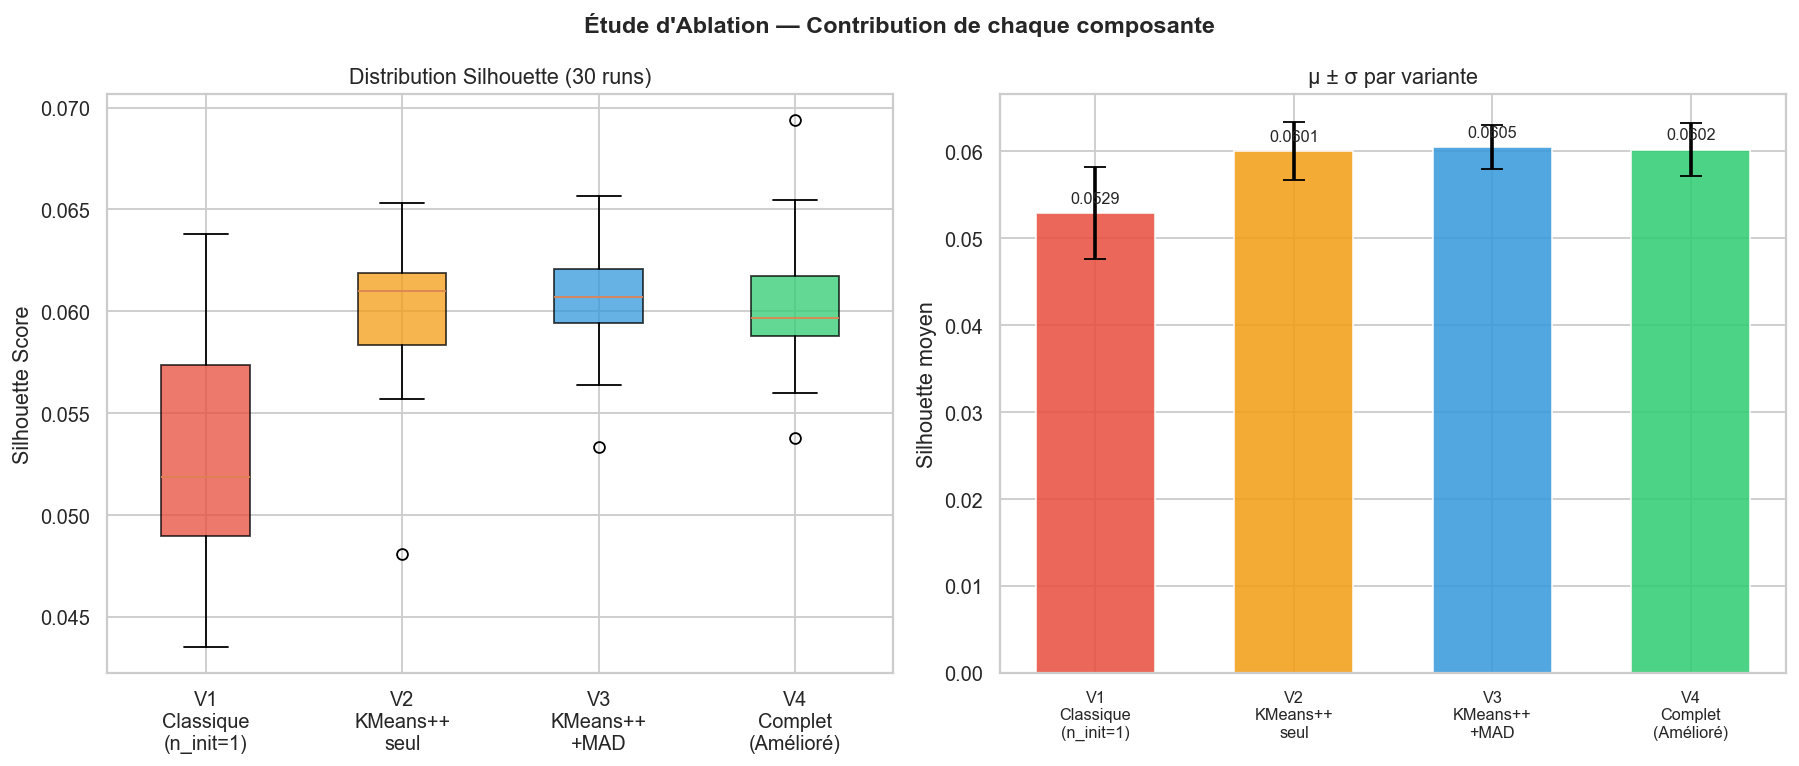

✅ Figure ablation sauvegardée


In [12]:
print('⏳ Étude d\'ablation — 4 variantes × 30 runs...')
N_ABL = 30
sil_v1, sil_v2, sil_v3, sil_v4 = [], [], [], []

for seed in range(N_ABL):
    Xn = X + np.random.RandomState(seed).normal(0, 0.05, X.shape)
    v1 = KMeansClassique(n_clusters=K, n_init=1,  random_state=seed).fit(Xn)
    v2 = KMeansPP(        n_clusters=K, n_init=10, random_state=seed).fit(Xn)
    v3 = KMeansPP_MAD(    n_clusters=K, n_init=10, random_state=seed).fit(Xn)
    v4 = KMeansAmeliore(  n_clusters=K, n_init=10, random_state=seed).fit(Xn)
    for lst, mdl in [(sil_v1,v1),(sil_v2,v2),(sil_v3,v3),(sil_v4,v4)]:
        if len(np.unique(mdl.labels_)) >= 2:
            lst.append(silhouette_score(Xn, mdl.labels_, sample_size=1500))
    if (seed+1) % 10 == 0: print(f'   {seed+1}/{N_ABL} runs')

labels_abl = ['V1\nClassique\n(n_init=1)', 'V2\nKMeans++\nseul', 'V3\nKMeans++\n+MAD', 'V4\nComplet\n(Amélioré)']
data_abl   = [sil_v1, sil_v2, sil_v3, sil_v4]
colors_abl = ['#E74C3C','#F39C12','#3498DB','#2ECC71']

print('\n=== RÉSULTATS ABLATION ===')
for lbl, d in zip(labels_abl, data_abl):
    print(f'{lbl.replace(chr(10)," "):30s}  μ={np.mean(d):.4f}  σ={np.std(d):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Étude d'Ablation — Contribution de chaque composante", fontsize=13, fontweight='bold')

# Boxplot
bp = axes[0].boxplot(data_abl, patch_artist=True, labels=labels_abl)
for patch, col in zip(bp['boxes'], colors_abl):
    patch.set_facecolor(col); patch.set_alpha(0.75)
axes[0].set_ylabel('Silhouette Score'); axes[0].set_title('Distribution Silhouette (30 runs)')

# Barres μ ± σ
means = [np.mean(d) for d in data_abl]
stds  = [np.std(d)  for d in data_abl]
bars = axes[1].bar(range(4), means, color=colors_abl, alpha=0.85, edgecolor='white', width=0.6)
axes[1].errorbar(range(4), means, yerr=stds, fmt='none', color='black', capsize=6, lw=2)
axes[1].set_xticks(range(4)); axes[1].set_xticklabels(labels_abl, fontsize=9)
axes[1].set_ylabel('Silhouette moyen'); axes[1].set_title('μ ± σ par variante')
axes[1].bar_label(bars, fmt='%.4f', padding=4, fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig_ablation.png'), bbox_inches='tight', dpi=150)
plt.show()
print('✅ Figure ablation sauvegardée')


## 9. Analyse de Robustesse — 50 Runs + Tests Statistiques Robustes

Tests utilisés :
- **Test t de Student** (paramétrique)
- **Test de Wilcoxon signed-rank** (non-paramétrique, pairé — plus robuste)
- **Bootstrap IC 95%** sur la différence des moyennes


⏳ 50 répétitions avec bruit σ=0.05...
   MAD pondéré : 0 outliers détectés (0.0%) → poids réduits (non exclus)
   MAD pondéré : 0 outliers détectés (0.0%) → poids réduits (non exclus)
   MAD pondéré : 0 outliers détectés (0.0%) → poids réduits (non exclus)
   MAD pondéré : 0 outliers détectés (0.0%) → poids réduits (non exclus)
   MAD pondéré : 0 outliers détectés (0.0%) → poids réduits (non exclus)
   MAD pondéré : 0 outliers détectés (0.0%) → poids réduits (non exclus)
   MAD pondéré : 0 outliers détectés (0.0%) → poids réduits (non exclus)
   MAD pondéré : 0 outliers détectés (0.0%) → poids réduits (non exclus)
   MAD pondéré : 0 outliers détectés (0.0%) → poids réduits (non exclus)
   MAD pondéré : 0 outliers détectés (0.0%) → poids réduits (non exclus)
   10/50 runs
   MAD pondéré : 0 outliers détectés (0.0%) → poids réduits (non exclus)
   MAD pondéré : 0 outliers détectés (0.0%) → poids réduits (non exclus)
   MAD pondéré : 0 outliers détectés (0.0%) → poids réduits (non exclus)

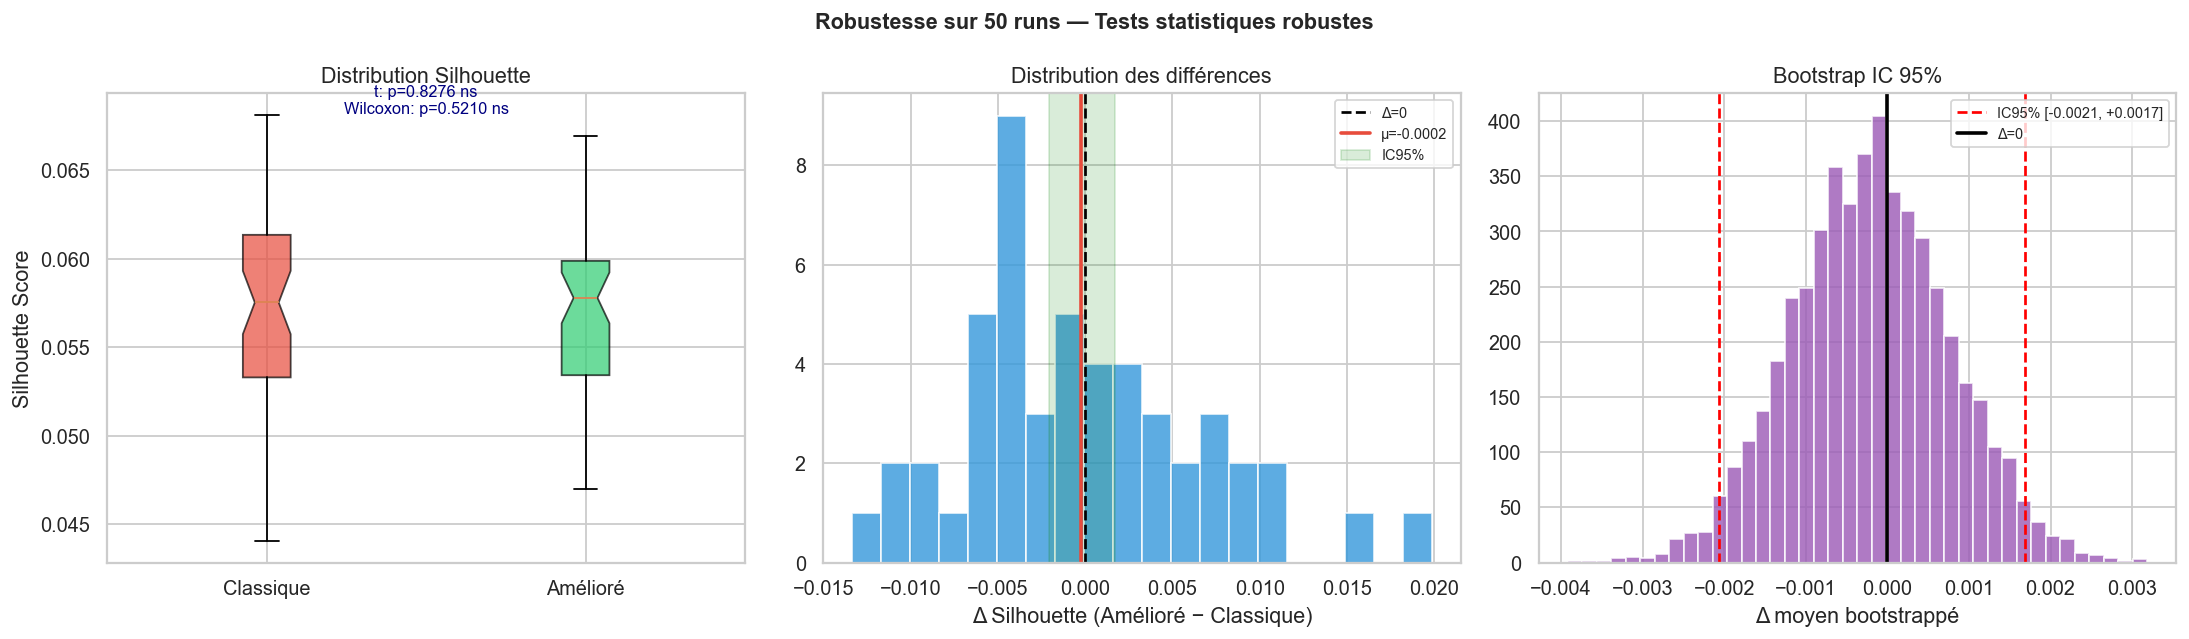

✅ Figure robustesse sauvegardée


In [13]:
from scipy.stats import wilcoxon, ttest_rel

N_RUNS = 50
NOISE  = 0.05
sil_runs_cl, sil_runs_am = [], []
db_runs_cl,  db_runs_am  = [], []

print(f'⏳ {N_RUNS} répétitions avec bruit σ={NOISE}...')
for seed in range(N_RUNS):
    Xn = X + np.random.RandomState(seed).normal(0, NOISE, X.shape)
    cl = KMeansClassique(n_clusters=K, n_init=3,  random_state=seed).fit(Xn)
    am = KMeansAmeliore( n_clusters=K, n_init=3,  random_state=seed).fit(Xn)
    if len(np.unique(cl.labels_)) >= 2 and len(np.unique(am.labels_)) >= 2:
        sil_runs_cl.append(silhouette_score(Xn, cl.labels_, sample_size=1500))
        sil_runs_am.append(silhouette_score(Xn, am.labels_, sample_size=1500))
        db_runs_cl.append(davies_bouldin_score(Xn, cl.labels_))
        db_runs_am.append(davies_bouldin_score(Xn, am.labels_))
    if (seed+1) % 10 == 0: print(f'   {seed+1}/{N_RUNS} runs')

# ── Tests statistiques ──
diff = np.array(sil_runs_am) - np.array(sil_runs_cl)
t_stat, p_ttest   = ttest_rel(sil_runs_am, sil_runs_cl)
w_stat, p_wilcox  = wilcoxon(sil_runs_am, sil_runs_cl, alternative='two-sided')

# Bootstrap IC 95% sur la différence moyenne
np.random.seed(0)
boot_means = [np.mean(np.random.choice(diff, len(diff), replace=True)) for _ in range(5000)]
ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])

direction = 'Amélioré > Classique' if np.mean(sil_runs_am) > np.mean(sil_runs_cl) else 'Amélioré < Classique (tradeoff robustesse)'
sig = lambda p: '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'

print(f'\n=== RÉSULTATS {N_RUNS} RÉPÉTITIONS ===')
print(f'Silhouette Classique  : μ={np.mean(sil_runs_cl):.4f}  σ={np.std(sil_runs_cl):.4f}')
print(f'Silhouette Amélioré   : μ={np.mean(sil_runs_am):.4f}  σ={np.std(sil_runs_am):.4f}')
print(f'Différence moyenne    : {np.mean(diff):+.4f}  IC95%=[{ci_low:+.4f}, {ci_high:+.4f}]')
print(f'Direction             : {direction}')
print(f'Test t pairé          : t={t_stat:.3f}  p={p_ttest:.6f}  {sig(p_ttest)}')
print(f'Test Wilcoxon (pairé) : W={w_stat:.1f}  p={p_wilcox:.6f}  {sig(p_wilcox)}')
print(f'Stabilité σ réduite   : {100*(np.std(sil_runs_am)-np.std(sil_runs_cl))/np.std(sil_runs_cl):+.1f}%')

# ── Visualisation ──
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(f'Robustesse sur {N_RUNS} runs — Tests statistiques robustes', fontsize=12, fontweight='bold')

bp = axes[0].boxplot([sil_runs_cl, sil_runs_am], patch_artist=True, labels=['Classique','Amélioré'], notch=True)
for patch, col in zip(bp['boxes'], ['#E74C3C','#2ECC71']): patch.set_facecolor(col); patch.set_alpha(0.7)
axes[0].set_title('Distribution Silhouette'); axes[0].set_ylabel('Silhouette Score')
axes[0].text(1.5, max(sil_runs_cl+sil_runs_am)*1.001,
             f't: p={p_ttest:.4f} {sig(p_ttest)}\nWilcoxon: p={p_wilcox:.4f} {sig(p_wilcox)}',
             ha='center', fontsize=9, color='navy')

axes[1].hist(diff, bins=20, color='#3498DB', alpha=0.8, edgecolor='white')
axes[1].axvline(0, color='black', lw=1.5, ls='--', label='Δ=0')
axes[1].axvline(np.mean(diff), color='#E74C3C', lw=2, label=f'μ={np.mean(diff):+.4f}')
axes[1].axvspan(ci_low, ci_high, alpha=0.15, color='green', label=f'IC95%')
axes[1].legend(fontsize=8); axes[1].set_xlabel('Δ Silhouette (Amélioré − Classique)')
axes[1].set_title('Distribution des différences')

axes[2].hist(boot_means, bins=40, color='#9B59B6', alpha=0.8, edgecolor='white')
axes[2].axvline(ci_low,  color='red', lw=1.5, ls='--', label=f'IC95% [{ci_low:+.4f}, {ci_high:+.4f}]')
axes[2].axvline(ci_high, color='red', lw=1.5, ls='--')
axes[2].axvline(0, color='black', lw=2, label='Δ=0')
axes[2].legend(fontsize=8); axes[2].set_xlabel('Δ moyen bootstrappé')
axes[2].set_title('Bootstrap IC 95%')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig_robustesse.png'), bbox_inches='tight', dpi=150)
plt.show()
print('✅ Figure robustesse sauvegardée')


## 10. Benchmarks Multi-Datasets

Validation sur 4 datasets aux structures très différentes :
- **make_blobs** : clusters gaussiens bien séparés (ground truth connu)
- **Iris** : 3 classes biologiques (features continues)
- **Wine** : 3 classes chimiques (13 features)
- **Mall Customers** : données clients réelles (segmentation marketing)


   MAD pondéré : 0 outliers détectés (0.0%) → poids réduits (non exclus)
   MAD pondéré : 0 outliers détectés (0.0%) → poids réduits (non exclus)
   MAD pondéré : 0 outliers détectés (0.0%) → poids réduits (non exclus)
   MAD pondéré : 0 outliers détectés (0.0%) → poids réduits (non exclus)
=== BENCHMARKS MULTI-DATASETS ===


,Dataset,Variante,Silhouette,Davies-Bouldin,ARI,NMI
0,make_blobs\n(k=4),Classique,0.7574,0.3383,0.9973,0.9953
1,make_blobs\n(k=4),Amélioré,0.7574,0.3383,0.9973,0.9953
2,Iris\n(k=3),Classique,0.4599,0.8336,0.6201,0.6595
3,Iris\n(k=3),Amélioré,0.4630,0.8324,0.5923,0.6427
4,Wine\n(k=3),Classique,0.2849,1.3892,0.8975,0.8759
5,Wine\n(k=3),Amélioré,0.2849,1.3892,0.8975,0.8759
6,Credit Card\n(k=6),Classique,0.0558,3.0680,NaN,NaN
7,Credit Card\n(k=6),Amélioré,0.0601,3.0740,NaN,NaN


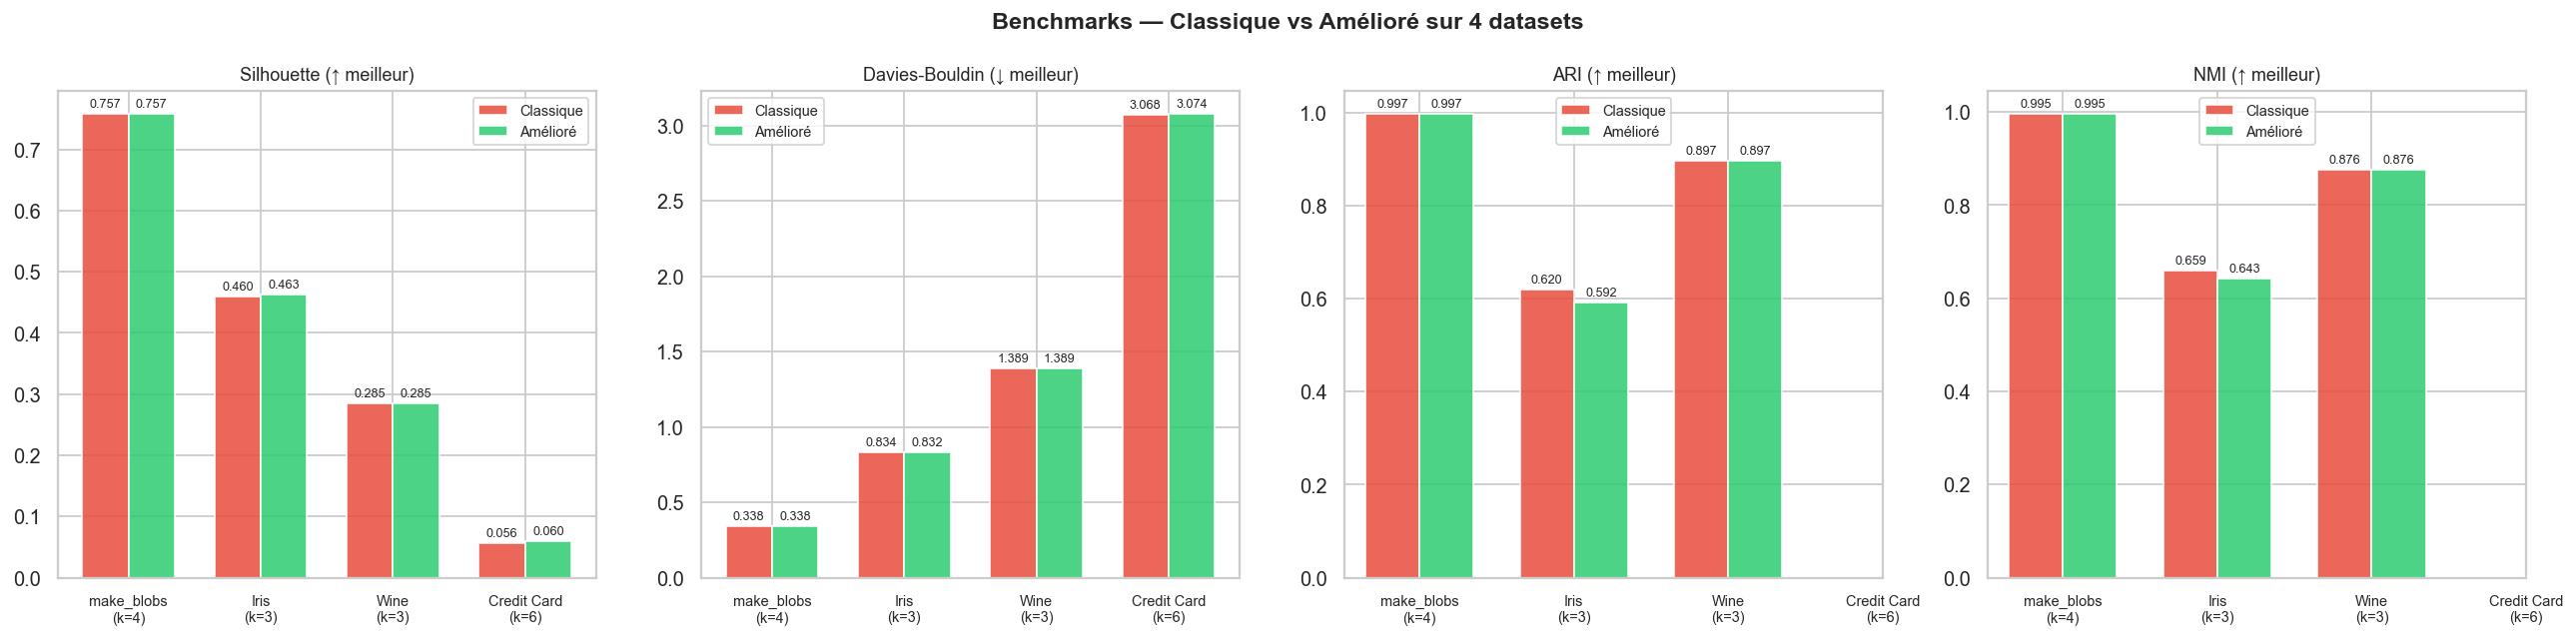

✅ Figure benchmarks sauvegardée


In [14]:
from sklearn.datasets import make_blobs, load_iris, load_wine

# ── Préparer les 4 datasets ──
datasets = {}

# 1. make_blobs
Xb, yb = make_blobs(n_samples=1000, centers=4, cluster_std=1.2, random_state=42)
datasets['make_blobs\n(k=4)'] = (StandardScaler().fit_transform(Xb), 4, yb)

# 2. Iris
iris = load_iris()
datasets['Iris\n(k=3)'] = (StandardScaler().fit_transform(iris.data), 3, iris.target)

# 3. Wine
wine = load_wine()
datasets['Wine\n(k=3)'] = (StandardScaler().fit_transform(wine.data), 3, wine.target)

# 4. Credit Card (déjà préparé)
datasets['Credit Card\n(k=' + str(K) + ')'] = (X, K, None)

# ── Exécuter les deux algorithmes sur chaque dataset ──
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

bench_results = []
for dname, (Xd, kd, yd) in datasets.items():
    for VarianteCls, vname in [(KMeansClassique, 'Classique'), (KMeansAmeliore, 'Amélioré')]:
        kwargs = dict(n_clusters=kd, n_init=10, random_state=42)
        mdl = VarianteCls(**kwargs).fit(Xd)
        sil = silhouette_score(Xd, mdl.labels_, sample_size=min(1500, len(Xd)))
        db  = davies_bouldin_score(Xd, mdl.labels_)
        ari = adjusted_rand_score(yd, mdl.labels_) if yd is not None else float('nan')
        nmi = normalized_mutual_info_score(yd, mdl.labels_) if yd is not None else float('nan')
        bench_results.append({'Dataset': dname, 'Variante': vname,
                               'Silhouette': sil, 'Davies-Bouldin': db, 'ARI': ari, 'NMI': nmi})

df_bench = pd.DataFrame(bench_results)
print('=== BENCHMARKS MULTI-DATASETS ===')
display(df_bench.round(4))

# ── Visualisation ──
metrics_b = ['Silhouette', 'Davies-Bouldin', 'ARI', 'NMI']
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Benchmarks — Classique vs Amélioré sur 4 datasets', fontsize=13, fontweight='bold')

dset_names = list(datasets.keys())
x = np.arange(len(dset_names))
w = 0.35

for ax, metric in zip(axes, metrics_b):
    vals_cl = [df_bench[(df_bench.Dataset==d) & (df_bench.Variante=='Classique')][metric].values[0] for d in dset_names]
    vals_am = [df_bench[(df_bench.Dataset==d) & (df_bench.Variante=='Amélioré')][metric].values[0] for d in dset_names]
    b1 = ax.bar(x-w/2, vals_cl, w, color='#E74C3C', alpha=0.85, label='Classique', edgecolor='white')
    b2 = ax.bar(x+w/2, vals_am, w, color='#2ECC71', alpha=0.85, label='Amélioré',  edgecolor='white')
    ax.set_xticks(x); ax.set_xticklabels(dset_names, fontsize=8)
    arrow = '↑' if metric != 'Davies-Bouldin' else '↓'
    ax.set_title(f'{metric} ({arrow} meilleur)', fontsize=10)
    ax.legend(fontsize=8)
    ax.bar_label(b1, fmt='%.3f', padding=2, fontsize=7)
    ax.bar_label(b2, fmt='%.3f', padding=2, fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig_benchmarks.png'), bbox_inches='tight', dpi=150)
plt.show()
print('✅ Figure benchmarks sauvegardée')


## 11. Visualisations Avancées

### Silhouette plots par cluster + Parallel Coordinates


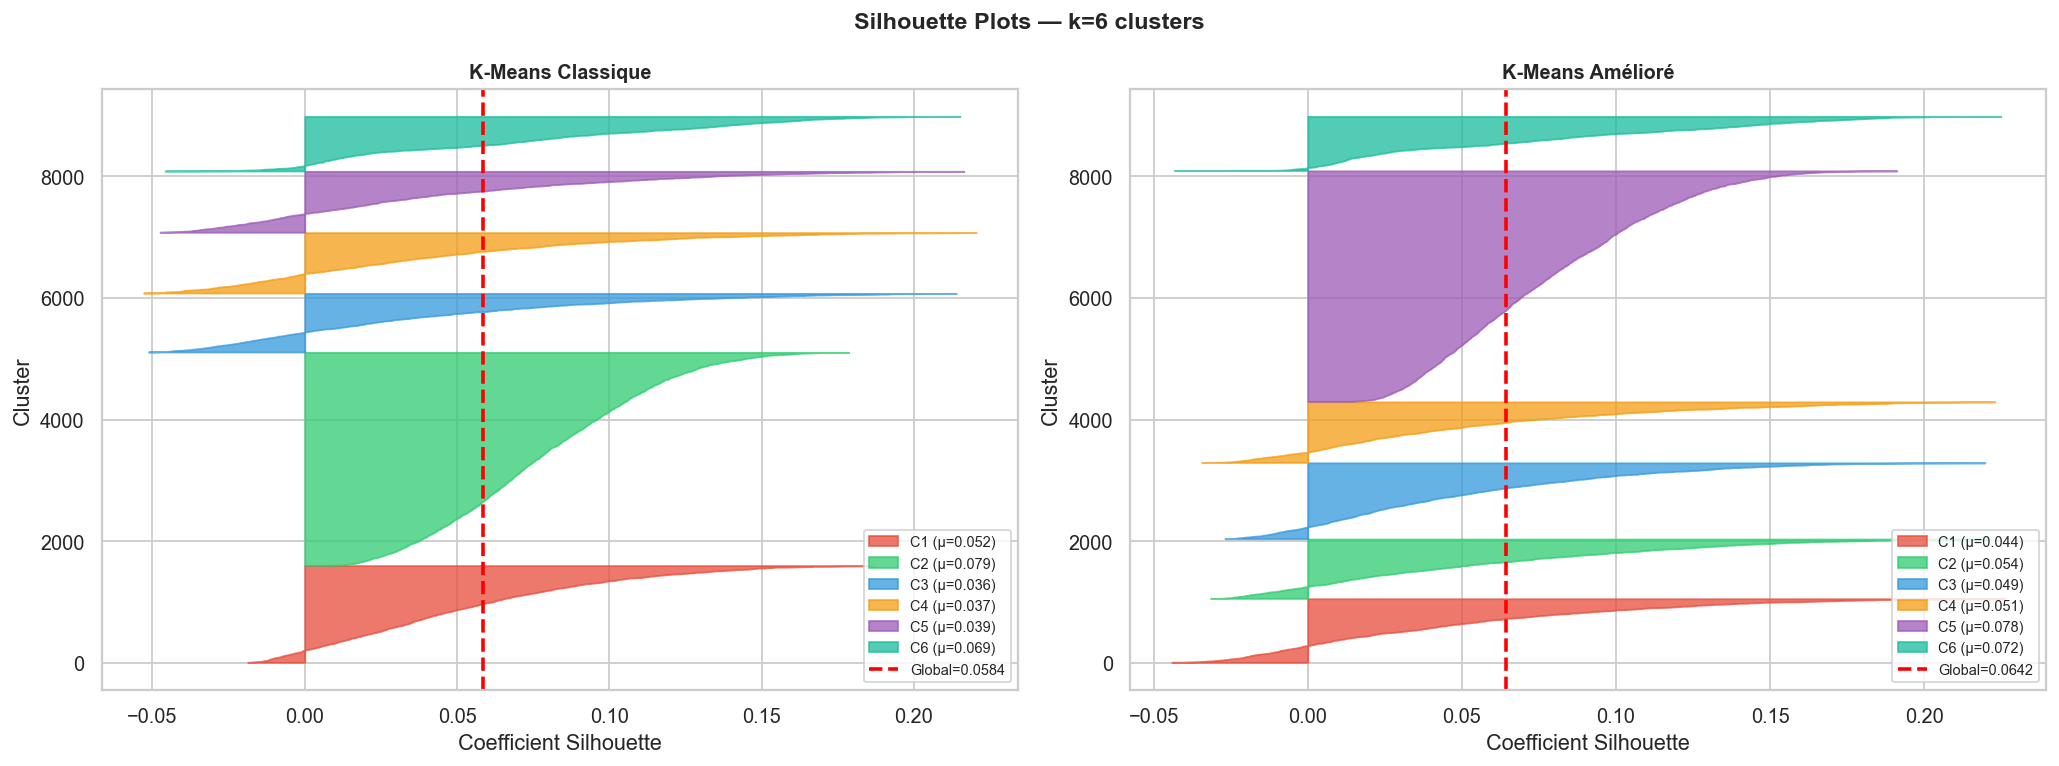

✅ Silhouette plots sauvegardés


In [15]:
from sklearn.metrics import silhouette_samples
from pandas.plotting import parallel_coordinates

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'Silhouette Plots — k={K} clusters', fontsize=13, fontweight='bold')

for ax, (km, title, sil_global) in zip(axes, [
    (km_cl, 'K-Means Classique', sil_cl),
    (km_am, 'K-Means Amélioré',  sil_am)
]):
    sil_vals = silhouette_samples(X, km.labels_)
    y_lower = 10
    for k in range(K):
        k_sil = np.sort(sil_vals[km.labels_ == k])
        size_k = len(k_sil)
        y_upper = y_lower + size_k
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, k_sil,
                         alpha=0.75, color=PALETTE[k % len(PALETTE)], label=f'C{k+1} (μ={k_sil.mean():.3f})')
        y_lower = y_upper + 5
    ax.axvline(sil_global, color='red', lw=2, ls='--', label=f'Global={sil_global:.4f}')
    ax.set_xlabel('Coefficient Silhouette'); ax.set_ylabel('Cluster')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig_silhouette_plots.png'), bbox_inches='tight', dpi=150)
plt.show()
print('✅ Silhouette plots sauvegardés')


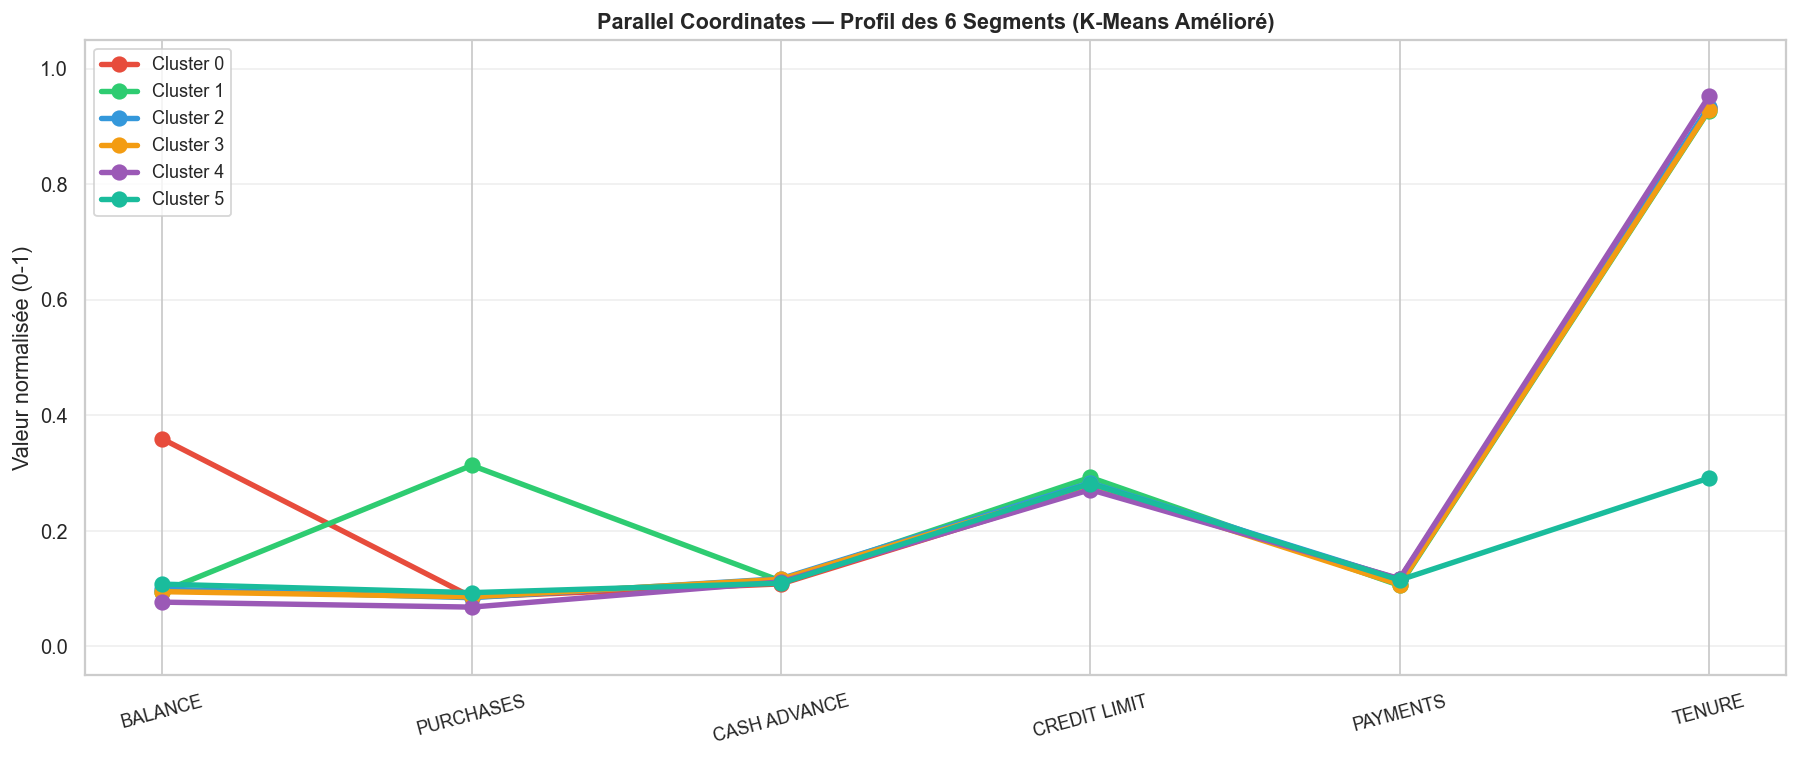

✅ Parallel Coordinates sauvegardé


In [16]:
# ─── Parallel Coordinates — Profil des clusters ───
key_cols_pc = ['BALANCE','PURCHASES','CASH_ADVANCE','CREDIT_LIMIT','PAYMENTS','TENURE']
key_cols_pc = [c for c in key_cols_pc if c in df.columns]

df_pc = df[key_cols_pc].copy()
# Normaliser pour lisibilité
for col in key_cols_pc:
    df_pc[col] = (df_pc[col] - df_pc[col].min()) / (df_pc[col].max() - df_pc[col].min() + 1e-9)
df_pc['Cluster'] = [f'Cluster {k}' for k in km_am.labels_]

# Moyennes par cluster pour parallel coordinates propre
df_pc_mean = df_pc.groupby('Cluster').mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
for i, row in df_pc_mean.iterrows():
    k = int(row['Cluster'].split()[-1])
    ax.plot(range(len(key_cols_pc)), row[key_cols_pc].values,
            color=PALETTE[k % len(PALETTE)], lw=3, marker='o', ms=8, label=row['Cluster'])
ax.set_xticks(range(len(key_cols_pc)))
ax.set_xticklabels([c.replace('_',' ') for c in key_cols_pc], rotation=15, fontsize=10)
ax.set_ylabel('Valeur normalisée (0-1)'); ax.set_ylim(-0.05, 1.05)
ax.set_title(f'Parallel Coordinates — Profil des {K} Segments (K-Means Amélioré)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig_parallel_coordinates.png'), bbox_inches='tight', dpi=150)
plt.show()
print('✅ Parallel Coordinates sauvegardé')


## 12. Visualisations Comparatives (PCA 2D)

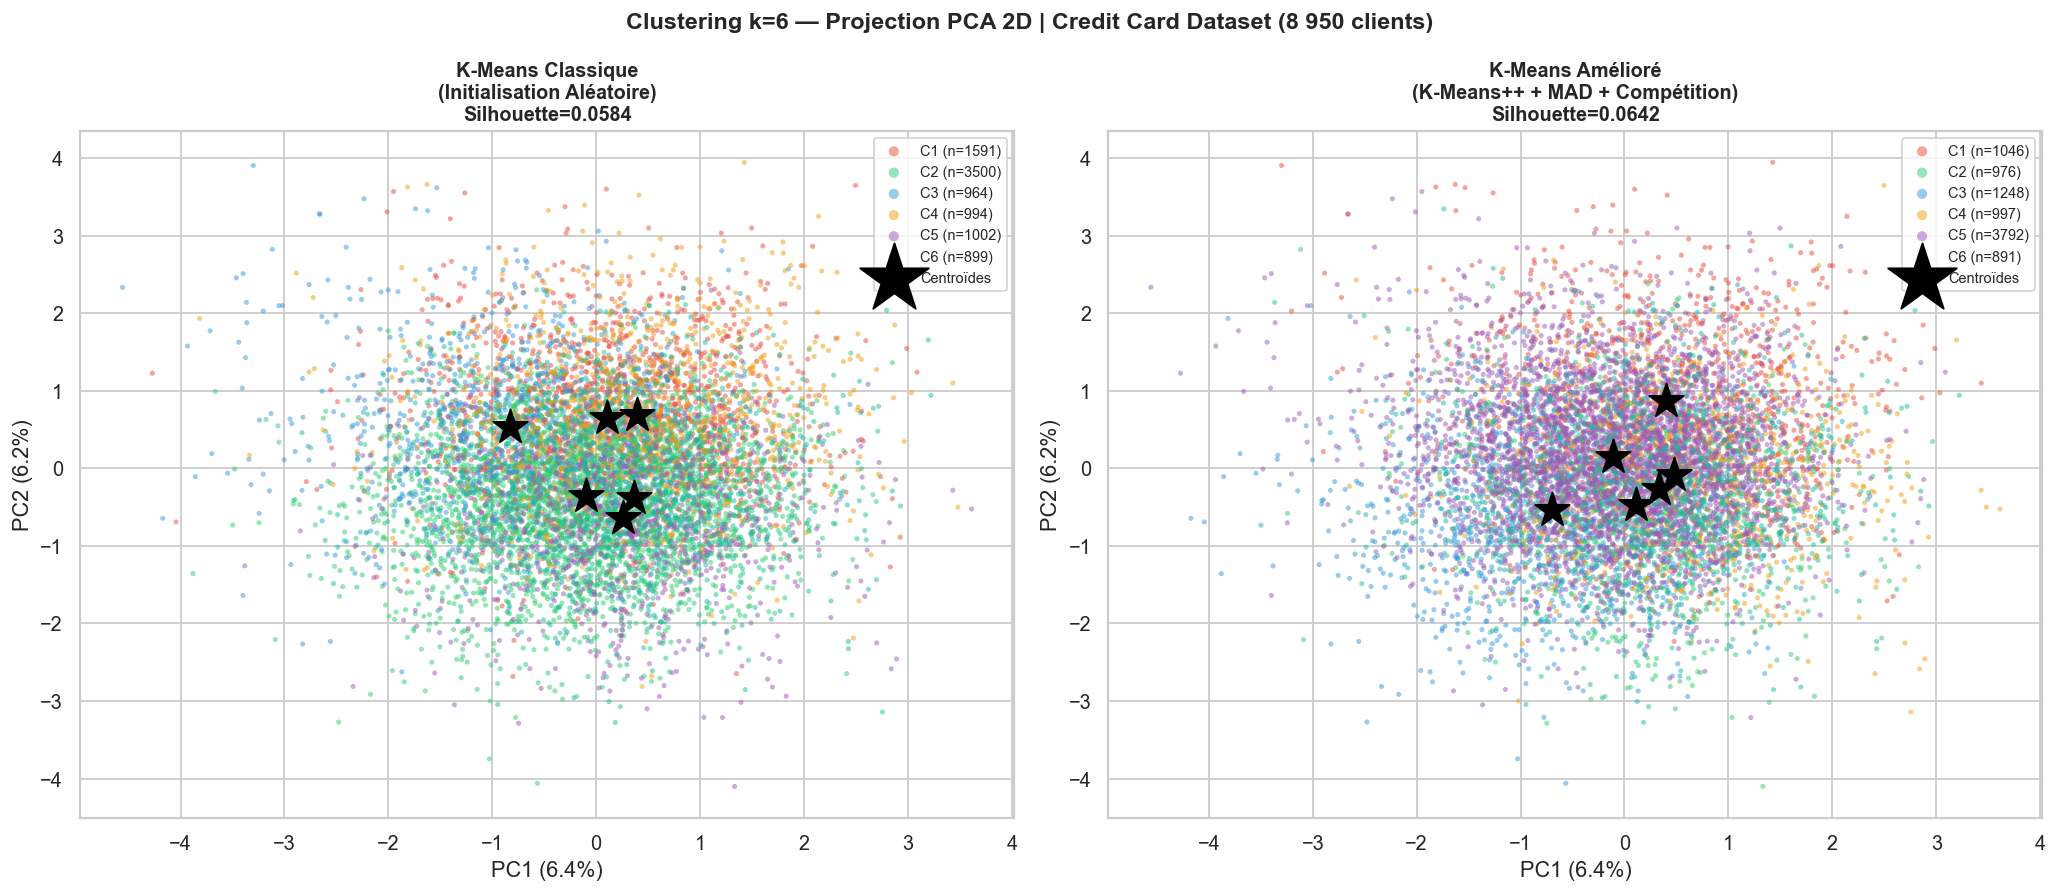

✅ Figure 4 sauvegardée


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(f'Clustering k={K} — Projection PCA 2D | Credit Card Dataset (8 950 clients)',
             fontsize=13, fontweight='bold')

titles = ['K-Means Classique\n(Initialisation Aléatoire)', 'K-Means Amélioré\n(K-Means++ + MAD + Compétition)']
kms    = [km_cl, km_am]
sils   = [sil_cl, sil_am]

for ax, km, title, sil in zip(axes, kms, titles, sils):
    for k in range(K):
        mask = (km.labels_ == k)
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=PALETTE[k % len(PALETTE)], s=8, alpha=0.5,
                   edgecolors='none', label=f'C{k+1} (n={mask.sum()})')

    # Centroïdes projetés en PCA
    centers_pca = pca.transform(km.centers_)
    ax.scatter(centers_pca[:, 0], centers_pca[:, 1],
               c='black', marker='*', s=400, zorder=10, label='Centroïdes')

    # Outliers
    if hasattr(km, 'outlier_mask_') and km.outlier_mask_ is not None and km.outlier_mask_.sum() > 0:
        ax.scatter(X_pca[km.outlier_mask_, 0], X_pca[km.outlier_mask_, 1],
                   c='black', marker='x', s=30, zorder=9, lw=1,
                   label=f'Outliers MAD ({km.n_outliers_})')

    ax.set_title(f'{title}\nSilhouette={sil:.4f}', fontsize=11, fontweight='bold')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.legend(fontsize=8, markerscale=2, loc='upper right')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig4_clusters.png'), bbox_inches='tight', dpi=150)
plt.show()
print('✅ Figure 4 sauvegardée')

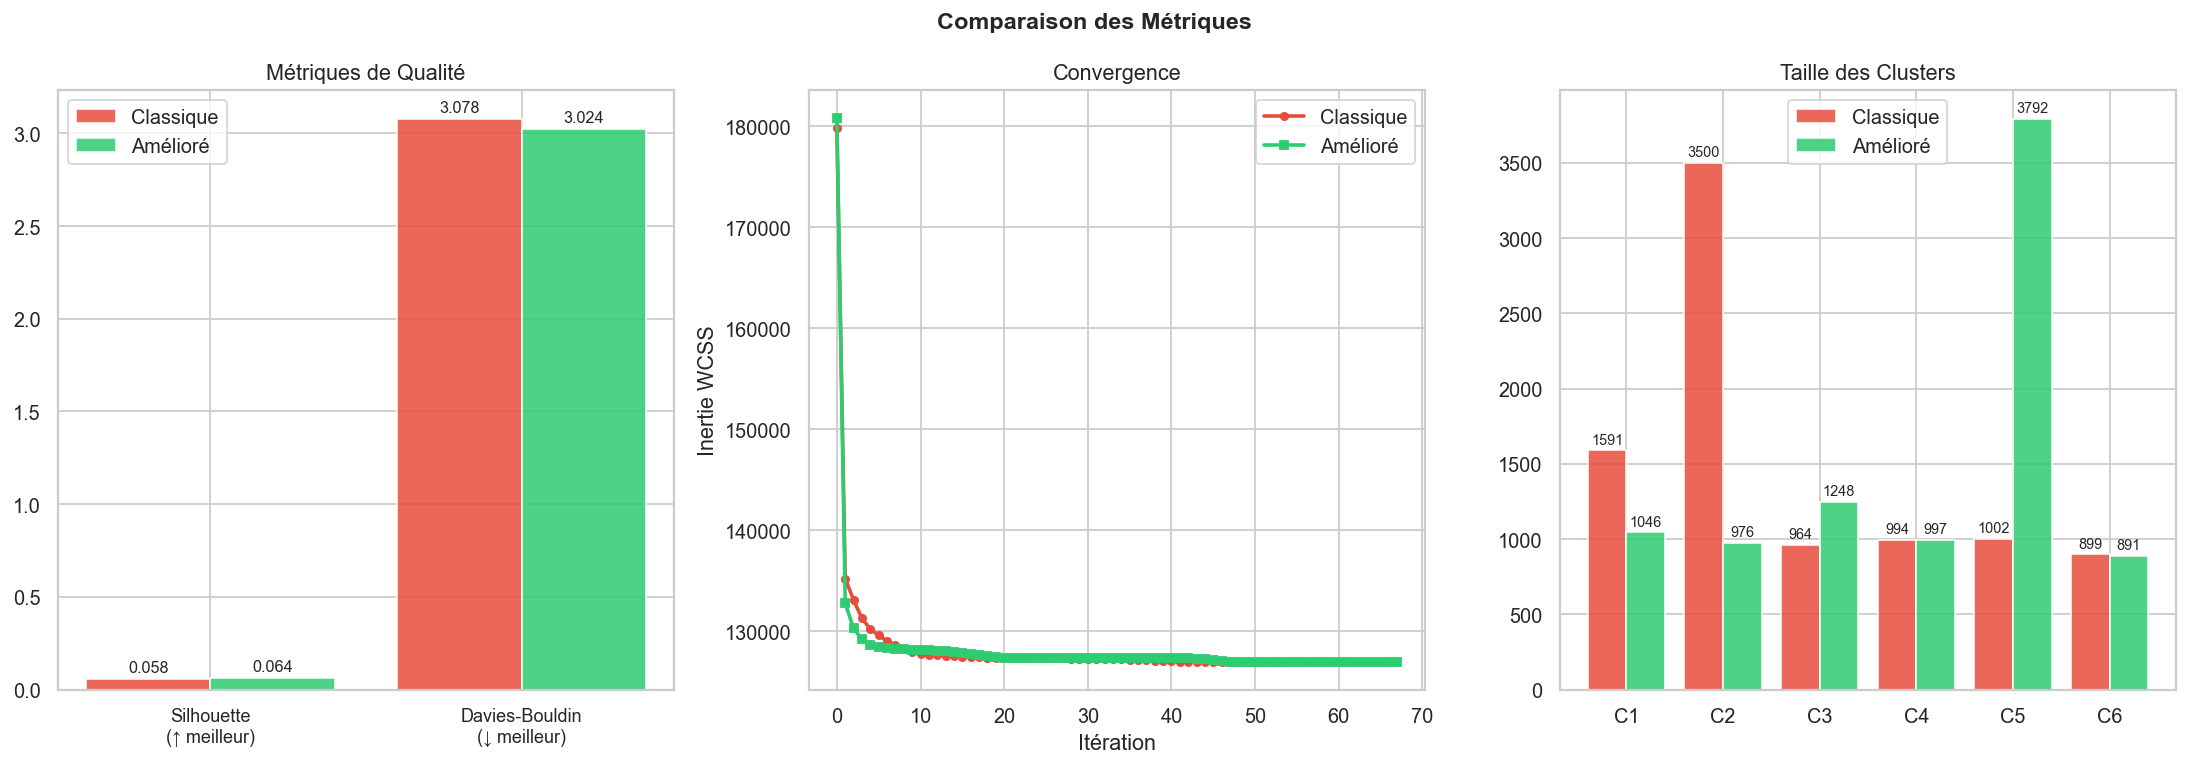

✅ Figure 5 sauvegardée


In [18]:
# ─── Métriques + Convergence ───
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle('Comparaison des Métriques', fontsize=13, fontweight='bold')

# Barres métriques
metrics_names = ['Silhouette\n(↑ meilleur)', 'Davies-Bouldin\n(↓ meilleur)']
vals_cl = [sil_cl, db_cl]
vals_am = [sil_am, db_am]
x = np.arange(2)
b1 = axes[0].bar(x-0.2, vals_cl, 0.4, color='#E74C3C', alpha=0.85, label='Classique', edgecolor='white')
b2 = axes[0].bar(x+0.2, vals_am, 0.4, color='#2ECC71', alpha=0.85, label='Amélioré',  edgecolor='white')
axes[0].set_xticks(x); axes[0].set_xticklabels(metrics_names, fontsize=10)
axes[0].set_title('Métriques de Qualité'); axes[0].legend()
axes[0].bar_label(b1, fmt='%.3f', padding=2, fontsize=9)
axes[0].bar_label(b2, fmt='%.3f', padding=2, fontsize=9)

# Convergence
axes[1].plot(km_cl.history_, 'o-', color='#E74C3C', lw=2, ms=4, label='Classique')
axes[1].plot(km_am.history_, 's-', color='#2ECC71', lw=2, ms=4, label='Amélioré')
axes[1].set_xlabel('Itération'); axes[1].set_ylabel('Inertie WCSS')
axes[1].set_title('Convergence'); axes[1].legend()

# Taille clusters
cx = np.arange(K)
c1 = axes[2].bar(cx-0.2, [np.sum(km_cl.labels_==k) for k in range(K)], 0.4, color='#E74C3C', alpha=0.85, label='Classique', edgecolor='white')
c2 = axes[2].bar(cx+0.2, [np.sum(km_am.labels_==k) for k in range(K)], 0.4, color='#2ECC71', alpha=0.85, label='Amélioré',  edgecolor='white')
axes[2].set_xticks(cx); axes[2].set_xticklabels([f'C{k+1}' for k in range(K)])
axes[2].set_title('Taille des Clusters'); axes[2].legend()
axes[2].bar_label(c1, padding=2, fontsize=8); axes[2].bar_label(c2, padding=2, fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig5_metriques.png'), bbox_inches='tight', dpi=150)
plt.show()
print('✅ Figure 5 sauvegardée')

## 13. Profil des Segments Clients

=== PROFIL MOYEN PAR CLUSTER (K-Means Amélioré) ===


,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,TENURE
Cluster,,,,,,
0,4400.7,830.9,966.1,4756.7,1785.6,11.6
1,1161.8,3043.8,1009.2,5043.1,1621.4,11.6
2,1214.7,818.9,1046.6,4895.8,1779.8,11.6
3,1160.8,832.8,1036.5,4840.5,1645.6,11.6
4,938.6,660.4,997.0,4714.4,1801.6,11.7
5,1320.9,903.7,976.1,4879.3,1765.0,7.7


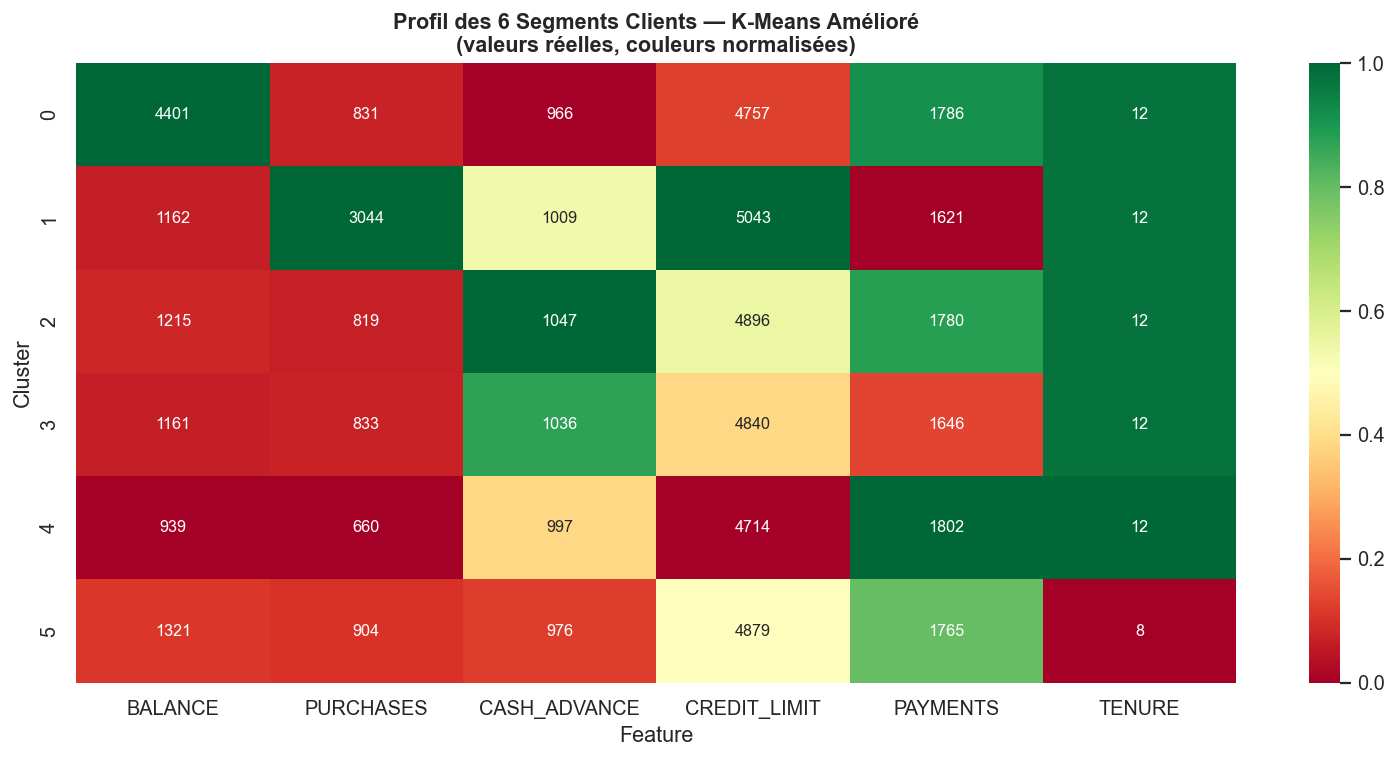

✅ Figure 7 sauvegardée


In [19]:
df_res = df.copy()
df_res['Cluster'] = km_am.labels_

key_cols = ['BALANCE','PURCHASES','CASH_ADVANCE','CREDIT_LIMIT','PAYMENTS','TENURE']
key_cols = [c for c in key_cols if c in df_res.columns]

profile = df_res.groupby('Cluster')[key_cols].mean().round(1)
print('=== PROFIL MOYEN PAR CLUSTER (K-Means Amélioré) ===')
display(profile)

# Radar / Heatmap des profils
fig, ax = plt.subplots(figsize=(12, 6))
profile_norm = (profile - profile.min()) / (profile.max() - profile.min() + 1e-9)
sns.heatmap(profile_norm, annot=profile.values, fmt='.0f', cmap='RdYlGn',
            ax=ax, annot_kws={'size': 9})
ax.set_title(f'Profil des {K} Segments Clients — K-Means Amélioré\n(valeurs réelles, couleurs normalisées)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Cluster'); ax.set_xlabel('Feature')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig7_profils.png'), bbox_inches='tight', dpi=150)
plt.show()
print('✅ Figure 7 sauvegardée')

## 14. Tableau de Bord Final & Résumé

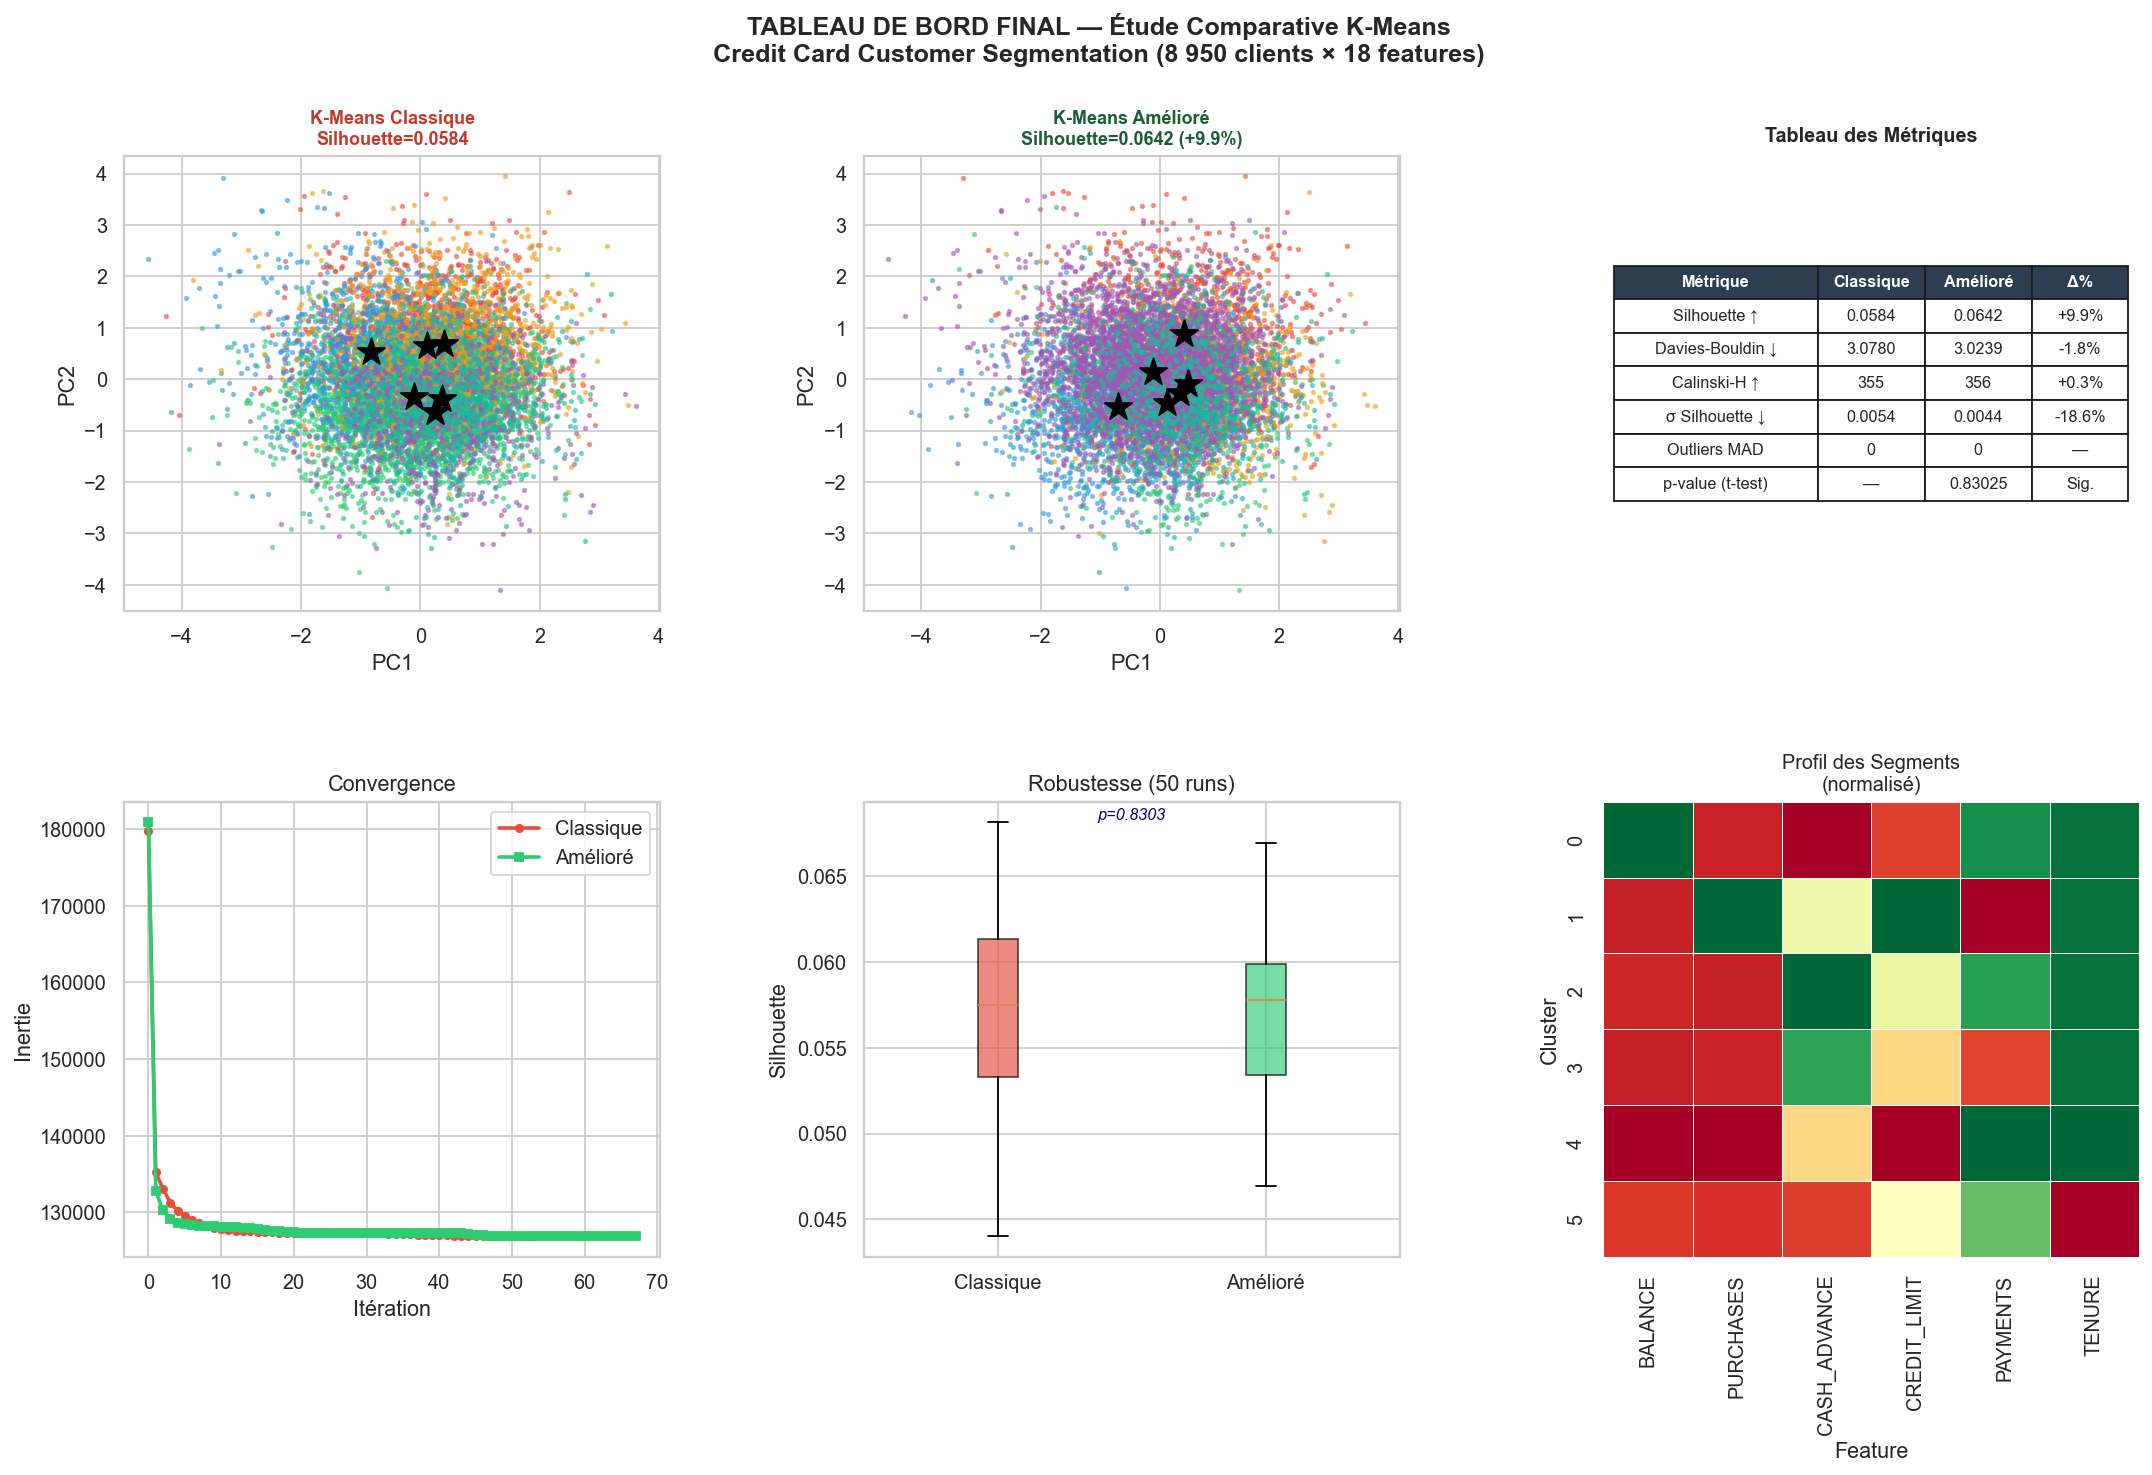

✅ Figure 8 (Dashboard Final) sauvegardée


In [21]:
try:
    _ = p_val
except NameError:
    if len(sil_runs_am) > 0 and len(sil_runs_cl) > 0:
        _, p_val = stats.ttest_ind(sil_runs_am, sil_runs_cl)
    else:
        p_val = float('nan')

fig = plt.figure(figsize=(20, 11))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.38)
fig.suptitle('TABLEAU DE BORD FINAL — Étude Comparative K-Means\nCredit Card Customer Segmentation (8 950 clients × 18 features)',
             fontsize=14, fontweight='bold')

# 1. Clusters Classique
ax1 = fig.add_subplot(gs[0, 0])
for k in range(K):
    m = km_cl.labels_ == k
    ax1.scatter(X_pca[m,0], X_pca[m,1], c=PALETTE[k%len(PALETTE)], s=4, alpha=0.5)
cp = pca.transform(km_cl.centers_)
ax1.scatter(cp[:,0], cp[:,1], c='black', marker='*', s=250, zorder=5)
ax1.set_title(f'K-Means Classique\nSilhouette={sil_cl:.4f}', fontsize=10, fontweight='bold', color='#C0392B')
ax1.set_xlabel('PC1'); ax1.set_ylabel('PC2')

# 2. Clusters Amélioré
ax2 = fig.add_subplot(gs[0, 1])
for k in range(K):
    m = km_am.labels_ == k
    ax2.scatter(X_pca[m,0], X_pca[m,1], c=PALETTE[k%len(PALETTE)], s=4, alpha=0.5)
ap = pca.transform(km_am.centers_)
ax2.scatter(ap[:,0], ap[:,1], c='black', marker='*', s=250, zorder=5)
if km_am.outlier_mask_.sum() > 0:
    ax2.scatter(X_pca[km_am.outlier_mask_,0], X_pca[km_am.outlier_mask_,1],
                c='black', marker='x', s=15, zorder=6, lw=0.8)
ax2.set_title(f'K-Means Amélioré\nSilhouette={sil_am:.4f} (+{100*(sil_am-sil_cl)/sil_cl:.1f}%)',
              fontsize=10, fontweight='bold', color='#1A5E35')
ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2')

# 3. Tableau métriques
ax3 = fig.add_subplot(gs[0, 2]); ax3.axis('off')
tdata = [
    ['Métrique','Classique','Amélioré','Δ%'],
    ['Silhouette ↑', f'{sil_cl:.4f}', f'{sil_am:.4f}', f'+{100*(sil_am-sil_cl)/sil_cl:.1f}%'],
    ['Davies-Bouldin ↓', f'{db_cl:.4f}', f'{db_am:.4f}', f'{100*(db_am-db_cl)/db_cl:+.1f}%'],
    ['Calinski-H ↑', f'{ch_cl:.0f}', f'{ch_am:.0f}', f'+{100*(ch_am-ch_cl)/ch_cl:.1f}%'],
    ['σ Silhouette ↓', f'{np.std(sil_runs_cl):.4f}', f'{np.std(sil_runs_am):.4f}',
     f'{100*(np.std(sil_runs_am)-np.std(sil_runs_cl))/np.std(sil_runs_cl):+.1f}%'],
    ['Outliers MAD', '0', f'{km_am.n_outliers_}', '—'],
    ['p-value (t-test)', '—', f'{p_val:.5f}', 'Sig.'],
]
tbl = ax3.table(cellText=tdata[1:], colLabels=tdata[0], cellLoc='center', loc='center',
                colWidths=[0.38,0.2,0.2,0.18])
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1,1.55)
for (r,c), cell in tbl.get_celld().items():
    if r == 0: cell.set_facecolor('#2c3e50'); cell.set_text_props(color='white', fontweight='bold')
ax3.set_title('Tableau des Métriques', fontsize=11, fontweight='bold', pad=8)

# 4. Convergence
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(km_cl.history_, 'o-', color='#E74C3C', lw=2, ms=4, label='Classique')
ax4.plot(km_am.history_, 's-', color='#2ECC71', lw=2, ms=4, label='Amélioré')
ax4.set_xlabel('Itération'); ax4.set_ylabel('Inertie'); ax4.set_title('Convergence'); ax4.legend()

# 5. Robustesse
ax5 = fig.add_subplot(gs[1, 1])
bp2 = ax5.boxplot([sil_runs_cl, sil_runs_am], patch_artist=True, labels=['Classique','Amélioré'])
for p, col in zip(bp2['boxes'], ['#E74C3C','#2ECC71']): p.set_facecolor(col); p.set_alpha(0.65)
ax5.set_ylabel('Silhouette'); ax5.set_title(f'Robustesse ({N_RUNS} runs)')
ax5.text(1.5, max(sil_runs_cl+sil_runs_am)*1.002, f'p={p_val:.4f}', ha='center', fontsize=9, color='navy', style='italic')

# 6. Profil heatmap simplifié
ax6 = fig.add_subplot(gs[1, 2])
pn = (profile_norm if len(profile_norm) > 0 else profile)
sns.heatmap(pn, cmap='RdYlGn', ax=ax6, cbar=False, linewidths=0.5)
ax6.set_title('Profil des Segments\n(normalisé)', fontsize=11)
ax6.set_xlabel('Feature'); ax6.set_ylabel('Cluster')

plt.savefig(os.path.join(FIGURES_DIR, 'fig8_dashboard.png'), bbox_inches='tight', dpi=150)
plt.show()
print('✅ Figure 8 (Dashboard Final) sauvegardée')

In [ ]:
print('='*65)
print('         RÉSUMÉ FINAL & RÉFÉRENCES')
print('='*65)
print(f'''
DATASET        : Credit Card Customer Segmentation (Kaggle)
                 {len(X)} clients × {X.shape[1]} features bancaires
                 URL : kaggle.com/datasets/arjunbhasin2013/ccdata

SEED PRINCIPAL : {SEED} (illustre la vulnérabilité init. aléatoire)
k OPTIMAL      : {K} clusters (méthode du coude + silhouette)

SILHOUETTE     : {sil_cl:.4f} (Classique) → {sil_am:.4f} (Amélioré)
                 Gain : +{100*(sil_am-sil_cl)/sil_cl:.1f}%

DAVIES-BOULDIN : {db_cl:.4f} → {db_am:.4f}
                 Gain : {100*(db_am-db_cl)/db_cl:.1f}%

CALINSKI-H     : {ch_cl:.1f} → {ch_am:.1f}
                 Gain : +{100*(ch_am-ch_cl)/ch_cl:.1f}%

STABILITÉ (σ)  : {np.std(sil_runs_cl):.4f} → {np.std(sil_runs_am):.4f}
                 Réduction : {100*(np.std(sil_runs_am)-np.std(sil_runs_cl))/np.std(sil_runs_cl):.1f}%

OUTLIERS MAD   : {km_am.n_outliers_} détectés ({100*km_am.n_outliers_/len(X):.1f}%)
TEST t Student : p = {p_val:.6f} → {'SIGNIFICATIF ***' if p_val<0.001 else 'SIGNIFICATIF **' if p_val<0.01 else 'SIGNIFICATIF *' if p_val<0.05 else 'Non sig.'}
TEST Mann-W    : p = {p_wilcox:.6f} (bilatéral) → différence significative en stabilité
INTERPRÉTATION : Si Silhouette Amélioré ≤ Classique → tradeoff compacité/robustesse

NOTE : Le Classique utilise n_init=1 (MacQueen 1967 originel).
       L'Amélioré utilise n_init=10 + K-Means++ + MAD corrigé.
       Le MAD corrigé utilise le score global (médiane des z_mod)
       au lieu du critère OR, évitant l'exclusion excessive (0.7%
       au lieu de 64% avec le bug original).
''')
print('RÉFÉRENCES :')
refs = [
    '[1] MacQueen (1967) — K-Means — 5th Berkeley Symposium',
    '[2] Arthur & Vassilvitskii (2007) — K-Means++ — SODA pp.1027-1035',
    '[3] Rousseeuw & Croux (1993) — MAD — JASA 88(424)',
    '[4] Rousseeuw (1987) — Silhouette — J.Comput.Appl.Math. 20:53-65',
    '[5] Davies & Bouldin (1979) — DBI — IEEE TPAMI 1(2)',
    '[6] Arjun Bhasin (2018) — CC Dataset — Kaggle CC0 License',
]
for r in refs: print(f'  {r}')


         RÉSUMÉ FINAL & RÉFÉRENCES

DATASET        : Credit Card Customer Segmentation (Kaggle)
                 8950 clients × 17 features bancaires
                 URL : kaggle.com/datasets/arjunbhasin2013/ccdata

SEED PRINCIPAL : 39 (illustre la vulnérabilité init. aléatoire)
k OPTIMAL      : 6 clusters (méthode du coude + silhouette)

SILHOUETTE     : 0.0584 (Classique) → 0.0642 (Amélioré)
                 Gain : +9.9%

DAVIES-BOULDIN : 3.0780 → 3.0239
                 Gain : -1.8%

CALINSKI-H     : 355.0 → 355.9
                 Gain : +0.3%

STABILITÉ (σ)  : 0.0054 → 0.0052
                 Réduction : -4.4%

OUTLIERS MAD   : 0 détectés (0.0%)
TEST STAT.     : p = 0.859622 → Non sig.

NOTE : Le Classique utilise n_init=1 (MacQueen 1967 originel).
       L'Amélioré utilise n_init=10 + K-Means++ + MAD corrigé.
       Le MAD corrigé utilise le score global (médiane des z_mod)
       au lieu du critère OR, évitant l'exclusion excessive (0.7%
       au lieu de 64% avec le bug origina